In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path("ADR_Eval.ipynb").resolve().parents[1]))


In [2]:
# !{sys.executable} -m pip install -U pandas

In [3]:
import h5py
import numpy as np
import os
import shutil
import json

In [4]:
from src.dataset import H5Snapshots, H5SubTrajectories, get_dataset, norm_u, inv_norm_u
from src.utils import seed_everything

from src.geometry import (
    iso_penalty_exact,
    iso_penalty_stochastic,
    operator_norm_loss,
    curvature_penalty
)

from src.node import (
    AffineModulatedLatentODEFunc, 
    integrate_latent_eval
)

from src.autoencoder import (
    SpatialCoherentEncoder, 
    SpatialCoherentDecoder, 
    infer_L_for_latent, 
    stiefel_project_conv_columns,
    eval_ae
)

In [5]:
path = "adr_full.h5"

mu_train, train_idx, val_idx, t_coarse, t_fine, coord_grid, Nmu, Nt_coarse, H, W = get_dataset(path) 

train/u_coarse: (1000, 200, 32, 32) float32
train/u_fine: (1000, 1000, 32, 32) float32
Inferred: (1000, 200, 32, 32)


In [6]:
# def recon_error

import torch
import torch.nn.functional as F
import numpy as np

@torch.no_grad()
def recon_error(enc, dec, dl, device=None, max_batches=None, return_per_batch=False):
    """
    Compute reconstruction MSE on a dataloader of snapshots x: (B,1,32,32).
    Returns:
      mse_pixel: mean squared error per pixel (averaged over all samples)
      mse_sample: mean squared error per sample (sum over pixels, averaged over samples)
    """
    if device is None:
        device = next(dec.parameters()).device

    enc.eval(); dec.eval()

    total_sq = 0.0      # sum of squared errors over all pixels in all samples
    total_pix = 0       # total number of pixels over all samples
    total_sse = 0.0     # sum of per-sample SSE
    total_n = 0         # total number of samples

    batch_stats = []
    for b, x in enumerate(dl):
        if max_batches is not None and b >= max_batches:
            break

        x = x.to(device, non_blocking=True)          # (B,1,32,32)
        z = enc(x)                                   # (B,1,4,4)
        xhat = dec(z)                                # (B,1,32,32)

        # pixel-wise SSE
        err = (xhat - x)
        sq = err.pow(2).sum().item()
        total_sq += sq
        total_pix += x.numel()

        # per-sample SSE (sum over pixels, avg over batch)
        sse_per_sample = err.flatten(1).pow(2).sum(dim=1)  # (B,)
        total_sse += sse_per_sample.sum().item()
        total_n += x.shape[0]

        if return_per_batch:
            batch_stats.append({
                "batch": b,
                "mse_pixel": sq / x.numel(),
                "mse_sample": float(sse_per_sample.mean().cpu()),
            })

    mse_pixel = total_sq / max(total_pix, 1)
    mse_sample = total_sse / max(total_n, 1)

    if return_per_batch:
        return mse_pixel, mse_sample, batch_stats
    return mse_pixel, mse_sample



In [7]:
experiments = {
    "vanilla": {
        "lam_reg": 0
    },
    "stoch_iso": {
        "lam_reg": 0.1
    },    
    "operator_norm": {
        "lam_reg": 0.1
    },
    "curvature": {
        "lam_reg": 0.1,
    },
    "stiefel": {
        "lam_reg": 0
    }
}

In [8]:
import torch


device = "cuda" if torch.cuda.is_available() else "cpu"
nmu = 3  # ADR params dimension

# EPOCHS = 100
# LR = 1e-3
T_max = float(t_coarse[-1])
latent_H = 4  # 4x4 => n=16
L = infer_L_for_latent(H=32, latent_H=latent_H)

L_max = 40

In [9]:
ds_train = H5Snapshots(path, split="train", field="u_coarse", mu_indices=train_idx, return_mu=False)
# ds_val   = H5Snapshots(path, split="train", field="u_coarse", mu_indices=val_idx, return_mu=False)

# ds_dyn_val = H5SubTrajectories(path, split="train", field="u_coarse", seed=0,
#                                  mu_indices=val_idx,   lmax=L_max, return_mu=True, fixed_k0=0)

umin, umax = ds_train.compute_train_minmax(field="u_coarse", mu_ids=train_idx, split="train")

umin, umax

(0.0, 3.2108547687530518)

In [38]:
import numpy as np
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def relative_error_curve(
    enc, dec, ode_func,
    h5_path,
    split="interp",
    field="u_coarse",
    mu_indices=None,
    horizon=40,
    start_ks=None,        # list[int] or None (then use n_starts linspace)
    n_starts=5,
    max_mu=None,
    method="rk2",
    device=None,
    eps=1e-8,
    drop_t0=True,         # drop t0 from ratios (useful when u0=0)
    return_cum_ratio=True, # also return ratio-of-sums curve (not Farenga primary)
    relative=True # if not, return MSE
):
    """
    Paper-style relative errors (Farenga):
      Eq (5.5):  rel(t) = ||u_hat(t)-u(t)||_2 / (||u(t)||_2 + eps)
      Eq (5.4):  rel_mu = mean_t rel(t)   (returned per window)
      Eq (5.7):  rel_sup = max_t rel(t)  (returned per window)

    Additionally (optional):
      cum_ratio(t) = (sum_{j<=t} ||e_j||^2) / (sum_{j<=t} ||u_j||^2 + eps)
      This is a useful diagnostic but is NOT Eq (5.5)/(5.4) in the paper.

    Returns:
      t_rel:         (L,) time from t0
      rel_mean:      (L,) mean over windows of rel(t)
      rel_se:        (L,) standard error over windows of rel(t)
      cum_mean:      (L,) mean over windows of cum_ratio(t)   (if return_cum_ratio)
      cum_se:        (L,) SE over windows of cum_ratio(t)     (if return_cum_ratio)
      per_win_rel:   (Nwin,L) raw rel(t) curves
      per_win_rel_mu:(Nwin,)  mean_t rel(t) per window   [Eq 5.4]
      per_win_rel_sup:(Nwin,) max_t rel(t) per window    [Eq 5.7]
    """
    import h5py

    if device is None:
        device = next(dec.parameters()).device
    enc.eval(); dec.eval(); ode_func.eval()

    with h5py.File(h5_path, "r") as f:
        U = f[f"{split}/{field}"]  # (Nmu, Nt, H, W)
        Nmu_all, Nt, Hx, Wx = U.shape

        t_np = f["t_coarse"][...] if "coarse" in field else f["t_fine"][...]
        t = torch.as_tensor(t_np, device=device, dtype=torch.float32)

        # mu ids
        if mu_indices is None:
            mu_ids = np.arange(Nmu_all, dtype=np.int64)
        else:
            mu_ids = np.asarray(mu_indices, dtype=np.int64)
        if max_mu is not None:
            mu_ids = mu_ids[:int(max_mu)]

        MU = f.get(f"{split}/mu", None)
        has_mu = MU is not None

        max_k0 = Nt - (horizon + 1)
        if max_k0 < 0:
            raise ValueError(f"{split}: Nt={Nt} too small for horizon={horizon}")

        # starts
        if start_ks is None:
            if n_starts <= 1:
                start_ks = [0]
            else:
                start_ks = np.linspace(0, max_k0, num=n_starts).round().astype(int).tolist()
        else:
            start_ks = [int(k) for k in start_ks if 0 <= int(k) <= max_k0]

        per_win_rel = []
        per_win_cum = []
        per_win_rel_mu = []
        per_win_rel_sup = []

        t_rel = None

        for i in mu_ids:
            if has_mu:
                mu = torch.from_numpy(MU[i].astype(np.float32)).to(device).unsqueeze(0)  # (1, nmu)
            else:
                mu = torch.zeros(1, 0, device=device)

            for k0 in start_ks:
                t_seg = t[k0:k0+horizon+1]  # (horizon+1,)
                if t_rel is None:
                    t_rel = (t_seg - t_seg[0]).detach().cpu().numpy()

                u0 = torch.from_numpy(U[i, k0].astype(np.float32))[None, None, ...].to(device)  # (1,1,H,W)
                u0 = norm_u(u0, umin, umax)
                
                z0 = enc(u0)

                z_traj = integrate_latent_eval(
                    ode_func, z0, t_seg.unsqueeze(0), mu, method=method
                )  # (1, horizon+1, 1, zH, zW)

                z_flat = z_traj.reshape(-1, *z_traj.shape[2:])               # (horizon+1,1,zH,zW)
                u_hat = dec(z_flat).reshape(1, horizon+1, 1, Hx, Wx)         # (1, horizon+1, 1, H, W)
                u_hat = inv_norm_u(u_hat, umin, umax)

                u_true = torch.from_numpy(
                    U[i, k0:k0+horizon+1].astype(np.float32)
                )[None, :, None, ...].to(device)                              # (1, horizon+1, 1, H, W)


                # print("u0:", u0.min(), u0.max(), u0.mean())
                # with torch.no_grad():
                #     urec = dec(enc(u0))
                # print("||u0||", torch.linalg.norm(u0).item(), "||urec-u0||", torch.linalg.norm(urec-u0).item())
                # import sys
                # sys.exit()                

                # Flatten spatial dims -> Euclidean vector norm approximating L2
                # num(t) = ||e(t)||_2, den(t) = ||u(t)||_2
                diff = (u_hat - u_true).reshape(1, horizon+1, -1)            # (1, L, HW)
                tru  = (u_true).reshape(1, horizon+1, -1)                    # (1, L, HW)

                num = torch.linalg.vector_norm(diff, dim=-1).squeeze(0)      # (L,)
                den = torch.linalg.vector_norm(tru,  dim=-1).squeeze(0)      # (L,)

                if drop_t0:
                    num = num[1:]
                    den = den[1:]

                if relative:
                    rel_t = num / (den + eps)                                    # (L',)  Eq (5.5)
                else:
                    rel_t = num

                per_win_rel.append(rel_t.detach().cpu().numpy())
                per_win_rel_mu.append(rel_t.mean().item())                  # Eq (5.4) over this window
                per_win_rel_sup.append(rel_t.max().item())                  # Eq (5.7) over this window

                if return_cum_ratio:
                    # Diagnostic: ratio-of-sums of squared norms (energy ratio), prefix in time
                    num2 = (diff.squeeze(0).pow(2).sum(dim=-1))              # (L,) = ||e||^2
                    den2 = (tru.squeeze(0).pow(2).sum(dim=-1))               # (L,) = ||u||^2
                    if drop_t0:
                        num2 = num2[1:]
                        den2 = den2[1:]
                    cum_num = torch.cumsum(num2, dim=0)
                    cum_den = torch.cumsum(den2, dim=0)

                    if relative:
                        cum_ratio = cum_num / (cum_den + eps)                   # (L',)
                    else:
                        cum_ratio = cum_num
                        
                    per_win_cum.append(cum_ratio.detach().cpu().numpy())

        per_win_rel = np.asarray(per_win_rel, dtype=np.float64)             # (Nwin, L')
        rel_mean = per_win_rel.mean(axis=0)
        rel_se = per_win_rel.std(axis=0, ddof=0) / np.sqrt(per_win_rel.shape[0])

        

        per_win_rel_mu = np.asarray(per_win_rel_mu, dtype=np.float64)       # (Nwin,)
        per_win_rel_sup = np.asarray(per_win_rel_sup, dtype=np.float64)     # (Nwin,)
        rel_sup_se = per_win_rel_sup.std(axis=0, ddof=0) / np.sqrt(per_win_rel_sup.shape[0])

        if drop_t0:
            t_rel_out = t_rel[1:]
        else:
            t_rel_out = t_rel

        if return_cum_ratio:
            per_win_cum = np.asarray(per_win_cum, dtype=np.float64)         # (Nwin, L')
            cum_mean = per_win_cum.mean(axis=0)
            cum_se = per_win_cum.std(axis=0, ddof=0) / np.sqrt(per_win_cum.shape[0])
        else:
            cum_mean = cum_se = per_win_cum = None

        return (t_rel_out, rel_mean, rel_se, cum_mean, cum_se,
                per_win_rel, per_win_rel_mu, per_win_rel_sup, rel_sup_se)


def plot_relative_error(t_rel, rel_mean, rel_se, cum_mean=None, cum_se=None, title=""):
    plt.figure()
    plt.plot(t_rel, rel_mean)
    plt.fill_between(t_rel, rel_mean - rel_se, rel_mean + rel_se, alpha=0.2)
    plt.xlabel("t - t0")
    plt.ylabel(r"$\|u-\hat u\|_2 / \|u\|_2$")
    plt.title(title + " | per-time relative L2 (Eq. 5.5)")
    plt.show()

    # if cum_mean is not None:
    #     plt.figure()
    #     plt.plot(t_rel, cum_mean)
    #     plt.fill_between(t_rel, cum_mean - cum_se, cum_mean + cum_se, alpha=0.2)
    #     plt.xlabel("t - t0")
    #     plt.ylabel(r"$\sum\|e\|^2 / (\sum\|u\|^2)$")
    #     plt.title(title + " | cumulative energy ratio (diagnostic)")
    #     plt.show()


In [11]:
from pathlib import Path
from typing import Callable, Iterable, Sequence, Tuple, Union, Optional, Dict, Any
import copy

import torch
import torch.nn as nn



from typing import Sequence, List, Tuple
import numpy as np


def select_k_closest_epochs(
    val_mse: Sequence[float],
    target: float,
    k: int,
    *,
    epoch_offset: int = 1,
    tie_break: str = "earlier",  # "earlier" or "later" (when same distance)
) -> Tuple[List[int], List[float]]:
    """
    Select k epochs whose val_mse is closest to a target value.

    Args:
        val_mse: sequence of validation MSE values, length = num_epochs
        target: target MSE to match
        k: number of epochs to select
        epoch_offset: epoch number corresponding to val_mse[0] (1 if epochs are 1..N)
        tie_break: for equal |val-target|, prefer "earlier" (smaller epoch) or "later"

    Returns:
        (epochs, values) where:
          epochs: list of selected epoch numbers (with epoch_offset applied)
          values: list of corresponding val_mse values
    """

    if k <= 0:
        raise ValueError("k must be positive")
    if k > len(val_mse):
        raise ValueError(f"k={k} > len(val_mse)={len(val_mse)}")

    v = np.asarray(val_mse, dtype=np.float64)
    dist = np.abs(v - float(target))

    idx = np.arange(len(v), dtype=np.int64)

    # lexsort sorts by last key first, so put primary key last
    if tie_break == "earlier":
        order = np.lexsort((idx, dist))          # dist asc, then epoch asc
    elif tie_break == "later":
        order = np.lexsort((-idx, dist))         # dist asc, then epoch desc
    else:
        raise ValueError('tie_break must be "earlier" or "later"')

    chosen = order[:k]
    epochs = (chosen + epoch_offset).tolist()
    values = v[chosen].tolist()
    return epochs, values


    
def _ema_update_(ema_sd: Dict[str, torch.Tensor],
                 new_sd: Dict[str, torch.Tensor],
                 decay: float) -> None:
    """
    In-place EMA update:
      ema = decay * ema + (1-decay) * new
    For non-floating tensors (e.g., num_batches_tracked), we copy from new.
    """
    for k, ema_v in ema_sd.items():
        new_v = new_sd[k]

        # Ensure same device/dtype where needed
        if torch.is_floating_point(ema_v) or torch.is_complex(ema_v):
            # promote new to ema dtype to avoid type mismatch
            new_v = new_v.to(device=ema_v.device, dtype=ema_v.dtype)
            ema_v.mul_(decay).add_(new_v, alpha=(1.0 - decay))
        else:
            # integers/bools: take latest
            ema_sd[k].copy_(new_v.to(device=ema_v.device))


def ema(
    val_mse: Sequence[float],
    k: int,
    ckpt_dir: Union[str, Path],
    *,
    ckpt_pattern: str = "ode_{epoch}.pt",
    epoch_offset: int = 1,
    mode: str = "min",          # "min" -> lowest val_mse is best
    decay: float = 0.9,
    map_location: Union[str, torch.device] = "cpu",
    strict: bool = True,
    save_path: Optional[Union[str, Path]] = None,
    method: "k_best",
    mse_target: float = 0.0,
) -> Tuple[nn.Module, torch.Tensor]:
    """
    Build an EMA-smoothed model from the top-k best epochs by val_mse.

    Args:
      val_mse: list of validation MSE per epoch (index 0 corresponds to epoch epoch_offset)
      k: number of best epochs to use
      ckpt_dir: folder containing checkpoints
      model_or_fn: either an existing model to deepcopy, or a factory fn returning a fresh model
      ckpt_pattern: filename pattern, must include "{epoch}" (e.g., "ode_{epoch}.pt")
      epoch_offset: epoch number corresponding to val_mse[0]. Common choices:
        - 1 if files are ode_1.pt ... ode_300.pt
        - 0 if files are ode_0.pt ... ode_299.pt
      mode: "min" or "max"
      decay: EMA decay (closer to 1 = smoother, less responsive)
      map_location: torch.load map_location
      strict: strict loading of state_dict into model
      save_path: if provided, saves {"state_dict": ema_state_dict, "epochs": ..., "decay": ...}

    Returns:
      (ema_model, best_epochs_tensor) where best_epochs_tensor are the epoch numbers used.
    """
    if "{epoch}" not in ckpt_pattern:
        raise ValueError('ckpt_pattern must include "{epoch}", e.g. "ode_{epoch}.pt"')

    if k <= 0:
        raise ValueError("k must be positive")
    if k > len(val_mse):
        raise ValueError(f"k={k} is larger than len(val_mse)={len(val_mse)}")
    if mode not in ("min", "max"):
        raise ValueError('mode must be "min" or "max"')
    if not (0.0 <= decay < 1.0):
        raise ValueError("decay must be in [0, 1)")

    ckpt_dir = Path(ckpt_dir)

    if method == "k_best":
        # Pick top-k epoch indices by metric
        scores = torch.tensor(list(val_mse), dtype=torch.float64)
        order = torch.argsort(scores, descending=(mode == "max"))
        top_idx = order[:k].tolist()                      # 0-based indices into val_mse
        best_epochs = torch.tensor([i + epoch_offset for i in top_idx], dtype=torch.long)

    elif method == "k_target":
        best_epochs, best_values = select_k_closest_epochs(list(val_mse), target=mse_target, k=k, epoch_offset=epoch_offset)
        best_epochs = torch.tensor(best_epochs, dtype=torch.long)

    # For "smoothing", it usually makes sense to apply EMA in chronological order.
    best_epochs_sorted = best_epochs.sort().values.tolist()
        
    ema_sd: Optional[Dict[str, torch.Tensor]] = None

    for j, ep in enumerate(best_epochs_sorted):
        ckpt_path = ckpt_dir / ckpt_pattern.format(epoch=ep)
        if not ckpt_path.exists():
            raise FileNotFoundError(
                f"Missing checkpoint: {ckpt_path}\n"
                f"Tip: if your checkpoints are 0-based/1-based, adjust epoch_offset "
                f"(currently epoch_offset={epoch_offset})."
            )

        ckpt = torch.load(ckpt_path, map_location=map_location, weights_only=False)
        sd = ckpt.state_dict()

        if ema_sd is None:
            # Initialize EMA with first checkpoint (clone tensors)
            ema_model = copy.deepcopy(ckpt)
            ema_model.to(map_location)
            ema_model.eval()            
            ema_sd = {k: v.detach().clone() for k, v in sd.items()}
        else:
            # Sanity: keys must match
            if ema_sd.keys() != sd.keys():
                missing = set(ema_sd.keys()) - set(sd.keys())
                extra = set(sd.keys()) - set(ema_sd.keys())
                raise KeyError(
                    "state_dict keys mismatch between checkpoints.\n"
                    f"Missing keys in new: {sorted(missing)[:10]}...\n"
                    f"Extra keys in new: {sorted(extra)[:10]}..."
                )
            _ema_update_(ema_sd, sd, decay=decay)

    assert ema_sd is not None
    ema_model.load_state_dict(ema_sd, strict=strict)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)

        torch.save(ema_model, save_path)
        # torch.save(
        #     {
        #         "state_dict": ema_sd,
        #         "epochs": best_epochs_sorted,
        #         "decay": decay,
        #         "ckpt_pattern": ckpt_pattern,
        #         "epoch_offset": epoch_offset,
        #     },
        #     save_path,
        # )

    return ema_model, best_epochs


In [1]:
import shutil

top_K = 3
AE_versions = [1]
NODE_runs = range(1,11)

for version in AE_versions:
    for run in NODE_runs:
        for exp_name in experiments.keys():

            run_dir = f"output/NODE/{exp_name}_v{version}/run_{run}/"

            # print(f"Processing {run_dir}...")
            filename = run_dir + "stats.json"

            val_mse_list = []
            with open(filename, "r") as f:
                data = json.load(f)
                val_mse_list = data["mse_val"]

            # EMA via top-k val
            ode, used_epochs = ema(
                    val_mse=val_mse_list,
                    k=top_K,
                    ckpt_dir=run_dir,
                    ckpt_pattern="ode_{epoch}.pt",
                    epoch_offset=1,
                    decay=0.9,
                    save_path=run_dir + "ode_ema.pt",
                    method="k_best",
                )
            
            # EMA via top-k close to target
            ode, used_epochs = ema(
                    val_mse=val_mse_list,
                    k=top_K,
                    ckpt_dir=run_dir,
                    ckpt_pattern="ode_{epoch}.pt",
                    epoch_offset=1,
                    decay=0.9,
                    save_path=run_dir + "ode_target.pt",
                    method="k_target",
                    mse_target = 2.1e-3,
                )

            target_ae_epoch = used_epochs[-1]

            # shutil.copy(run_dir+f"enc_ft_{target_ae_epoch}.pt", run_dir+"enc_ft_target.pt")
            # shutil.copy(run_dir+f"dec_ft_{target_ae_epoch}.pt", run_dir+"dec_ft_target.pt")

            
            # print("EMA built from epochs:", used_epochs.tolist(), "\n") 

NameError: name 'experiments' is not defined



----------------------------------------------------------------------------------------------------
vanilla - V_1, run 1
----------------------------------------------------------------------------------------------------


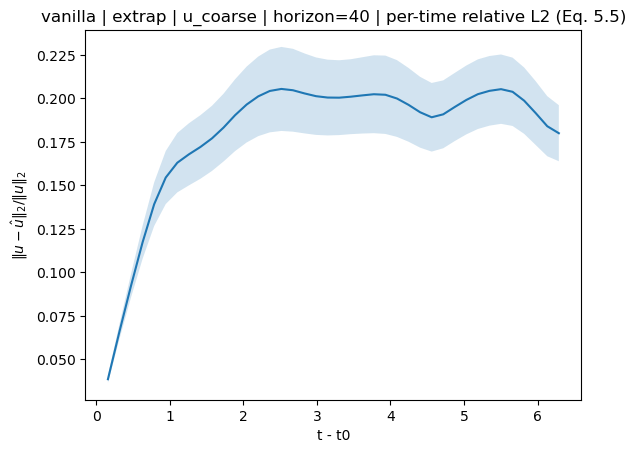

{'exp_name': 'vanilla', 'mse_max': np.float64(0.8431860208511353), 'mse_max_ci': np.float64(0.02791418469067276), 'mse_fin': np.float64(0.17997590877115727), 'mse_fin_ci': np.float64(0.01610398248081784), 'mse_cum_fin': np.float64(0.03746142705436796), 'mse_cum_fin_ci': np.float64(0.004973316987546234)}


----------------------------------------------------------------------------------------------------
stoch_iso - V_1, run 1
----------------------------------------------------------------------------------------------------


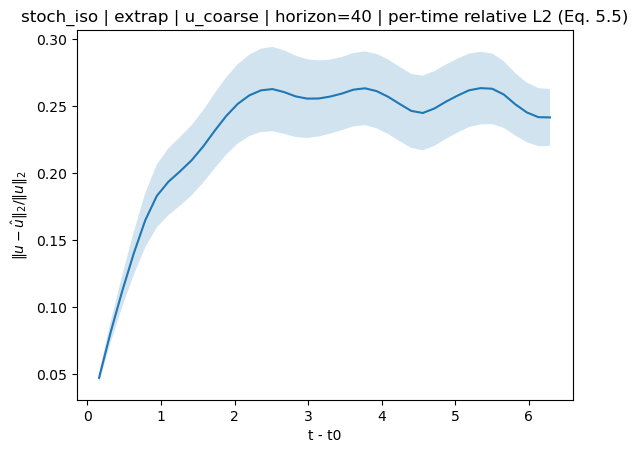

{'exp_name': 'stoch_iso', 'mse_max': np.float64(1.1656842231750488), 'mse_max_ci': np.float64(0.038098977236252426), 'mse_fin': np.float64(0.24169510543346406), 'mse_fin_ci': np.float64(0.021271316455884502), 'mse_cum_fin': np.float64(0.06196268146857619), 'mse_cum_fin_ci': np.float64(0.008683031866773955)}


----------------------------------------------------------------------------------------------------
operator_norm - V_1, run 1
----------------------------------------------------------------------------------------------------


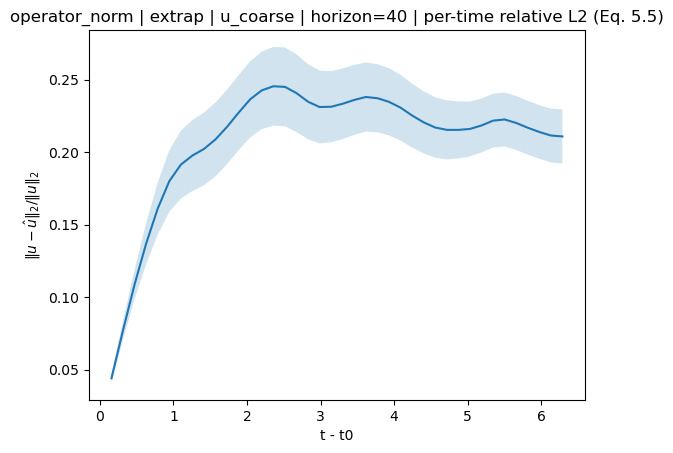

{'exp_name': 'operator_norm', 'mse_max': np.float64(0.9088734984397888), 'mse_max_ci': np.float64(0.03289412512895664), 'mse_fin': np.float64(0.21088130258023738), 'mse_fin_ci': np.float64(0.018761602202021343), 'mse_cum_fin': np.float64(0.049064772399142385), 'mse_cum_fin_ci': np.float64(0.006119260727502526)}


----------------------------------------------------------------------------------------------------
curvature - V_1, run 1
----------------------------------------------------------------------------------------------------


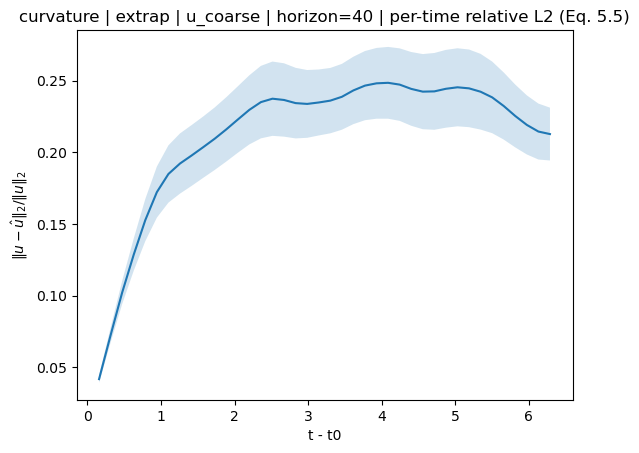

{'exp_name': 'curvature', 'mse_max': np.float64(1.0034950971603394), 'mse_max_ci': np.float64(0.033189694406933784), 'mse_fin': np.float64(0.21274874731898308), 'mse_fin_ci': np.float64(0.018443444435369497), 'mse_cum_fin': np.float64(0.051545458352193235), 'mse_cum_fin_ci': np.float64(0.006828392764092644)}


----------------------------------------------------------------------------------------------------
stiefel - V_1, run 1
----------------------------------------------------------------------------------------------------


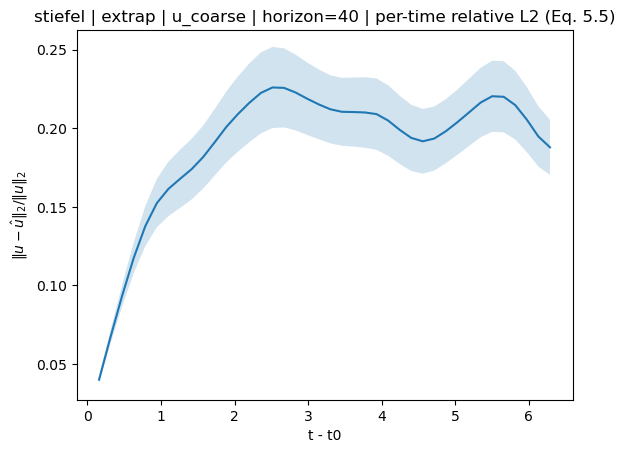

{'exp_name': 'stiefel', 'mse_max': np.float64(0.8666620850563049), 'mse_max_ci': np.float64(0.029865522712134687), 'mse_fin': np.float64(0.18787643626332284), 'mse_fin_ci': np.float64(0.017580577827899218), 'mse_cum_fin': np.float64(0.04126721827313304), 'mse_cum_fin_ci': np.float64(0.005531506142528896)}


----------------------------------------------------------------------------------------------------
vanilla - V_1, run 2
----------------------------------------------------------------------------------------------------


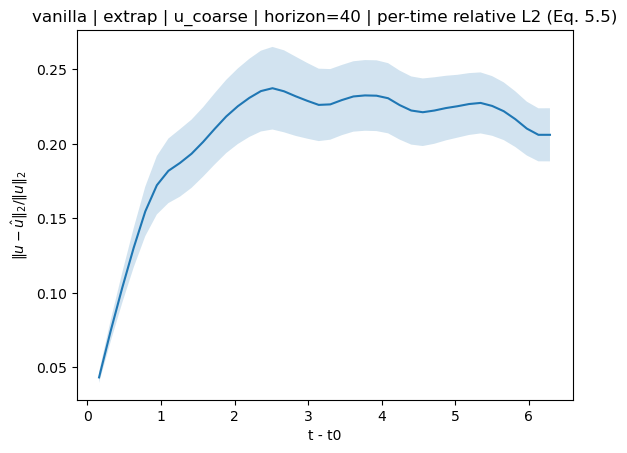

{'exp_name': 'vanilla', 'mse_max': np.float64(0.9643668532371521), 'mse_max_ci': np.float64(0.032106609329303315), 'mse_fin': np.float64(0.2060990008711815), 'mse_fin_ci': np.float64(0.01782387126215324), 'mse_cum_fin': np.float64(0.04803008363582194), 'mse_cum_fin_ci': np.float64(0.006401717495813255)}


----------------------------------------------------------------------------------------------------
stoch_iso - V_1, run 2
----------------------------------------------------------------------------------------------------


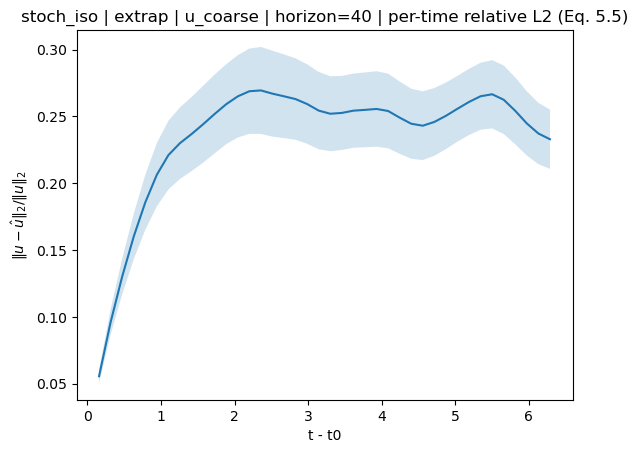

{'exp_name': 'stoch_iso', 'mse_max': np.float64(1.0638574361801147), 'mse_max_ci': np.float64(0.038019721381095634), 'mse_fin': np.float64(0.2328939440846443), 'mse_fin_ci': np.float64(0.02216584841065916), 'mse_cum_fin': np.float64(0.0638268524594605), 'mse_cum_fin_ci': np.float64(0.008732864530957788)}


----------------------------------------------------------------------------------------------------
operator_norm - V_1, run 2
----------------------------------------------------------------------------------------------------


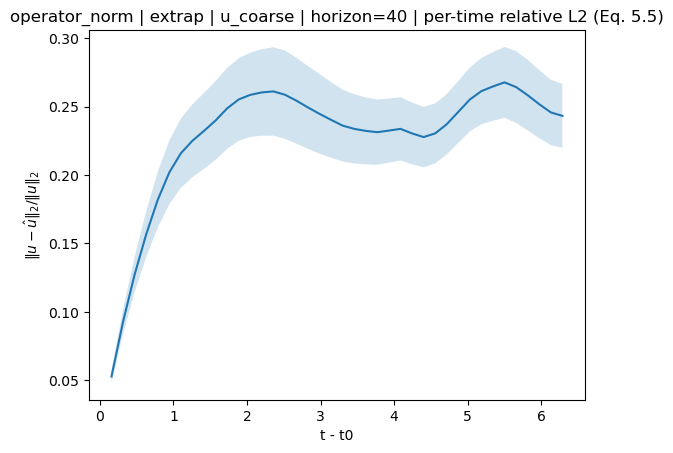

{'exp_name': 'operator_norm', 'mse_max': np.float64(1.0458145141601562), 'mse_max_ci': np.float64(0.03655151155619022), 'mse_fin': np.float64(0.24325091078877448), 'mse_fin_ci': np.float64(0.023292780472240544), 'mse_cum_fin': np.float64(0.05971484607085586), 'mse_cum_fin_ci': np.float64(0.007888157067233363)}


----------------------------------------------------------------------------------------------------
curvature - V_1, run 2
----------------------------------------------------------------------------------------------------


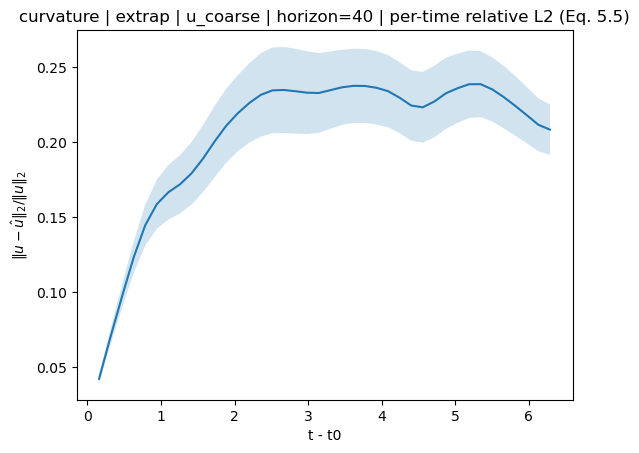

{'exp_name': 'curvature', 'mse_max': np.float64(0.982650637626648), 'mse_max_ci': np.float64(0.032505776838932875), 'mse_fin': np.float64(0.20843839257955551), 'mse_fin_ci': np.float64(0.016826580569972795), 'mse_cum_fin': np.float64(0.048244256107136604), 'mse_cum_fin_ci': np.float64(0.006583682563136614)}


----------------------------------------------------------------------------------------------------
stiefel - V_1, run 2
----------------------------------------------------------------------------------------------------


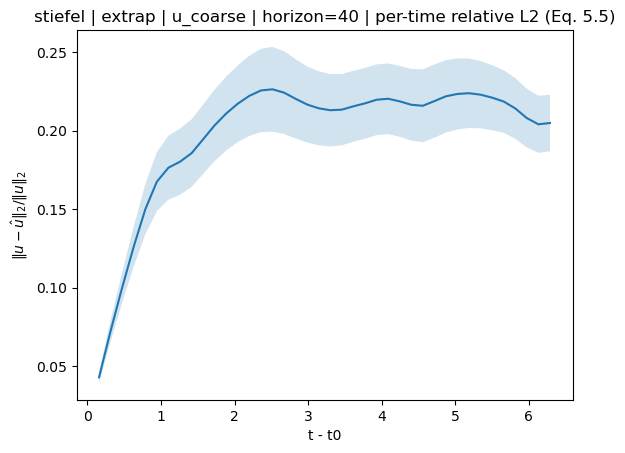

{'exp_name': 'stiefel', 'mse_max': np.float64(0.9623709321022034), 'mse_max_ci': np.float64(0.031065558862221176), 'mse_fin': np.float64(0.20481912642717362), 'mse_fin_ci': np.float64(0.017980275926464874), 'mse_cum_fin': np.float64(0.04499336279928684), 'mse_cum_fin_ci': np.float64(0.006006294080005349)}


----------------------------------------------------------------------------------------------------
vanilla - V_1, run 3
----------------------------------------------------------------------------------------------------


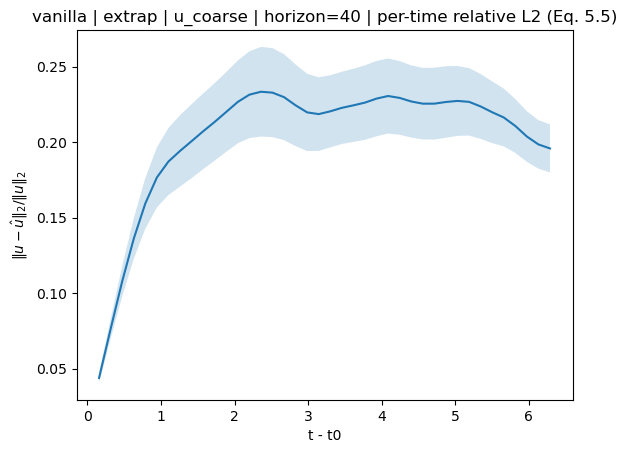

{'exp_name': 'vanilla', 'mse_max': np.float64(0.9774491190910339), 'mse_max_ci': np.float64(0.03281474816771971), 'mse_fin': np.float64(0.19588835880160332), 'mse_fin_ci': np.float64(0.01591733467871522), 'mse_cum_fin': np.float64(0.04788905487395823), 'mse_cum_fin_ci': np.float64(0.006653531698662289)}


----------------------------------------------------------------------------------------------------
stoch_iso - V_1, run 3
----------------------------------------------------------------------------------------------------


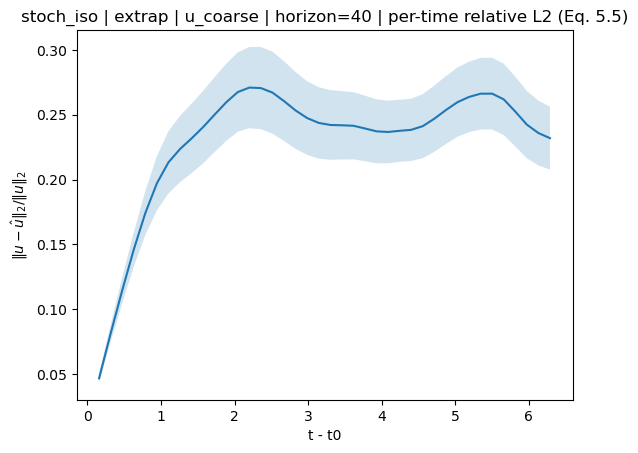

{'exp_name': 'stoch_iso', 'mse_max': np.float64(1.012976050376892), 'mse_max_ci': np.float64(0.03739130015066282), 'mse_fin': np.float64(0.23193640656769277), 'mse_fin_ci': np.float64(0.02424958557004323), 'mse_cum_fin': np.float64(0.060512041952461), 'mse_cum_fin_ci': np.float64(0.007781329064481753)}


----------------------------------------------------------------------------------------------------
operator_norm - V_1, run 3
----------------------------------------------------------------------------------------------------


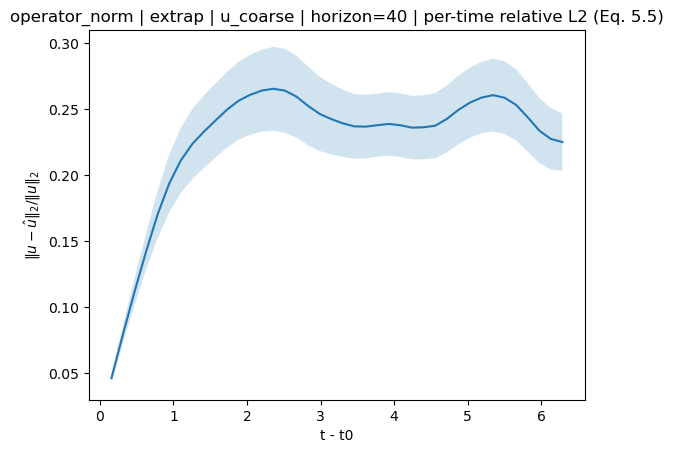

{'exp_name': 'operator_norm', 'mse_max': np.float64(1.0407873392105103), 'mse_max_ci': np.float64(0.036813378118396925), 'mse_fin': np.float64(0.22519812799990177), 'mse_fin_ci': np.float64(0.021863295482668684), 'mse_cum_fin': np.float64(0.05841034146025777), 'mse_cum_fin_ci': np.float64(0.007479264317674127)}


----------------------------------------------------------------------------------------------------
curvature - V_1, run 3
----------------------------------------------------------------------------------------------------


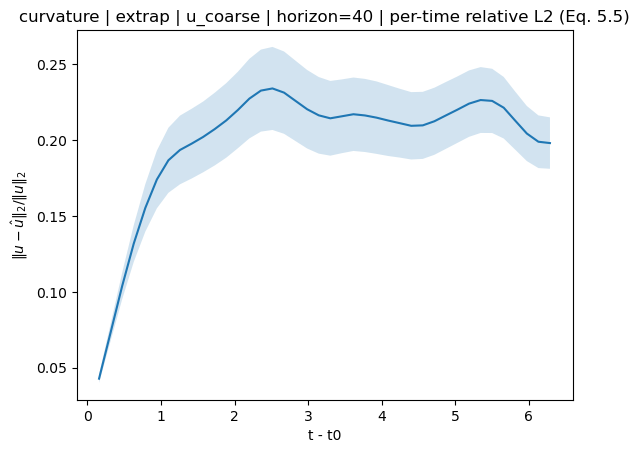

{'exp_name': 'curvature', 'mse_max': np.float64(0.957719087600708), 'mse_max_ci': np.float64(0.03216070781807253), 'mse_fin': np.float64(0.19793343223631382), 'mse_fin_ci': np.float64(0.01692862823748845), 'mse_cum_fin': np.float64(0.04571653295308351), 'mse_cum_fin_ci': np.float64(0.006350846502984488)}


----------------------------------------------------------------------------------------------------
stiefel - V_1, run 3
----------------------------------------------------------------------------------------------------


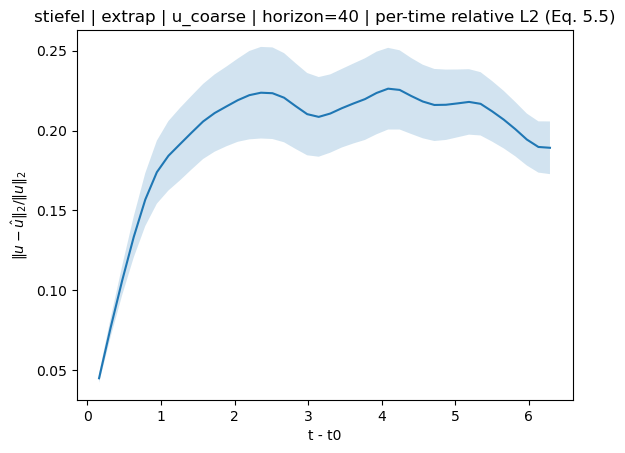

{'exp_name': 'stiefel', 'mse_max': np.float64(0.9942940473556519), 'mse_max_ci': np.float64(0.032021726821115974), 'mse_fin': np.float64(0.18921298086643218), 'mse_fin_ci': np.float64(0.016500873939702718), 'mse_cum_fin': np.float64(0.045001891488209364), 'mse_cum_fin_ci': np.float64(0.006633241084956586)}


----------------------------------------------------------------------------------------------------
vanilla - V_1, run 4
----------------------------------------------------------------------------------------------------


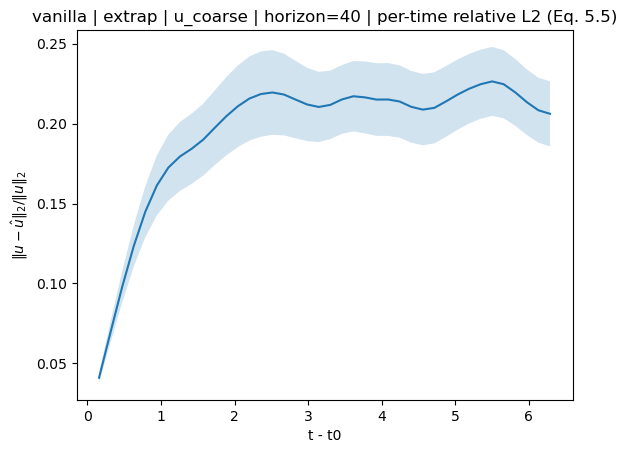

{'exp_name': 'vanilla', 'mse_max': np.float64(0.9716431498527527), 'mse_max_ci': np.float64(0.03195650379349541), 'mse_fin': np.float64(0.20617468968033792), 'mse_fin_ci': np.float64(0.020386223649145815), 'mse_cum_fin': np.float64(0.04378321307711303), 'mse_cum_fin_ci': np.float64(0.005886705468961671)}


----------------------------------------------------------------------------------------------------
stoch_iso - V_1, run 4
----------------------------------------------------------------------------------------------------


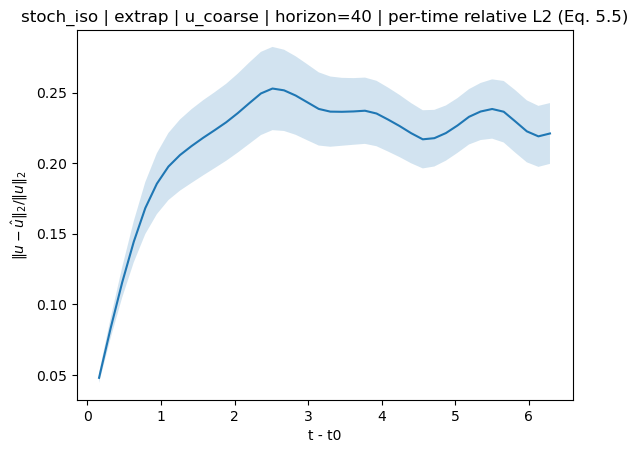

{'exp_name': 'stoch_iso', 'mse_max': np.float64(0.9886649250984192), 'mse_max_ci': np.float64(0.03436703069176174), 'mse_fin': np.float64(0.22107600688934326), 'mse_fin_ci': np.float64(0.02155353340200293), 'mse_cum_fin': np.float64(0.05230569371953606), 'mse_cum_fin_ci': np.float64(0.006845189316453624)}


----------------------------------------------------------------------------------------------------
operator_norm - V_1, run 4
----------------------------------------------------------------------------------------------------


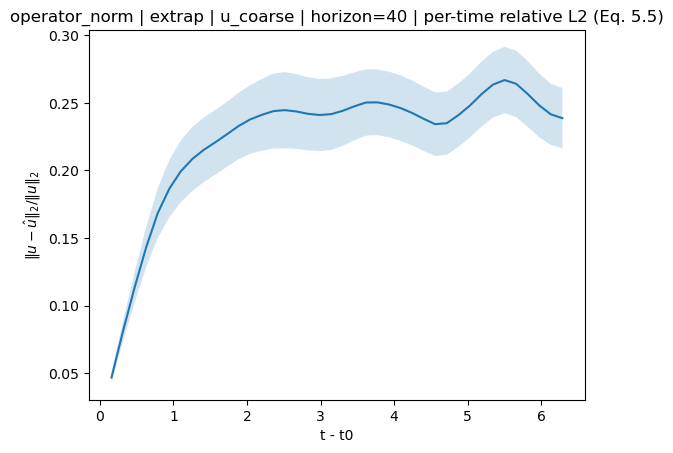

{'exp_name': 'operator_norm', 'mse_max': np.float64(0.9979467391967773), 'mse_max_ci': np.float64(0.03447707277033864), 'mse_fin': np.float64(0.23865202754735948), 'mse_fin_ci': np.float64(0.02235664996605672), 'mse_cum_fin': np.float64(0.05703488533385098), 'mse_cum_fin_ci': np.float64(0.007527902157047545)}


----------------------------------------------------------------------------------------------------
curvature - V_1, run 4
----------------------------------------------------------------------------------------------------


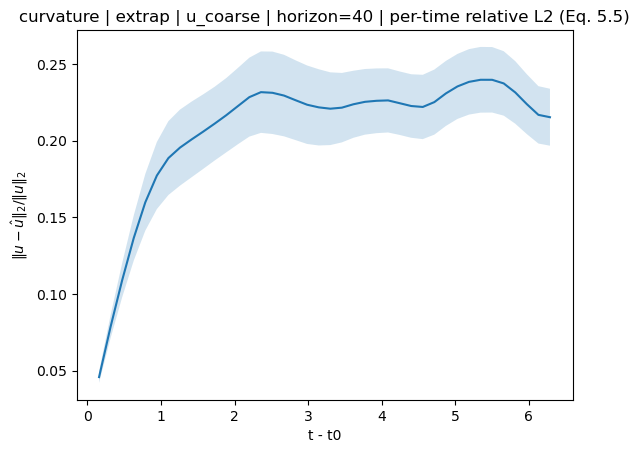

{'exp_name': 'curvature', 'mse_max': np.float64(0.9187941551208496), 'mse_max_ci': np.float64(0.032066824795998164), 'mse_fin': np.float64(0.21530759878456593), 'mse_fin_ci': np.float64(0.018579161020268613), 'mse_cum_fin': np.float64(0.04843106055632233), 'mse_cum_fin_ci': np.float64(0.006070893570818094)}


----------------------------------------------------------------------------------------------------
stiefel - V_1, run 4
----------------------------------------------------------------------------------------------------


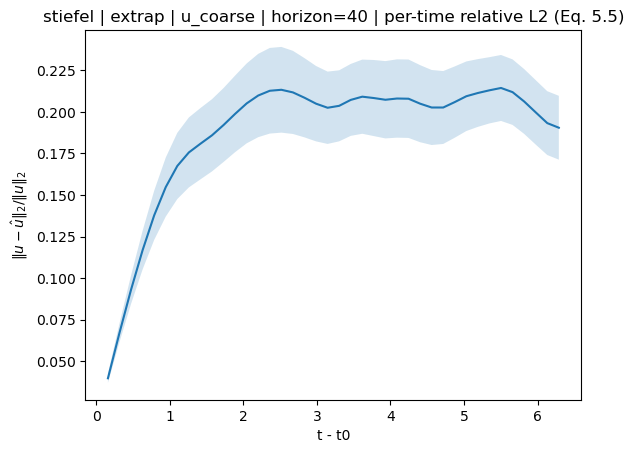

{'exp_name': 'stiefel', 'mse_max': np.float64(0.9609037041664124), 'mse_max_ci': np.float64(0.03145323813299991), 'mse_fin': np.float64(0.1904824620485306), 'mse_fin_ci': np.float64(0.019201687912046735), 'mse_cum_fin': np.float64(0.04049034051597118), 'mse_cum_fin_ci': np.float64(0.005498312119575582)}


----------------------------------------------------------------------------------------------------
vanilla - V_1, run 5
----------------------------------------------------------------------------------------------------


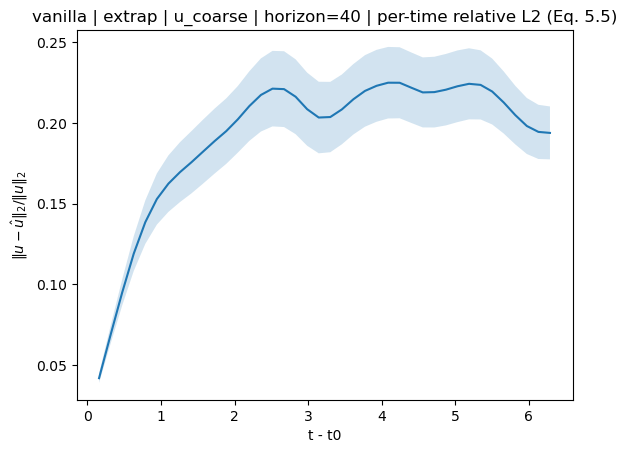

{'exp_name': 'vanilla', 'mse_max': np.float64(0.9353289008140564), 'mse_max_ci': np.float64(0.02829782350743314), 'mse_fin': np.float64(0.19391062662005423), 'mse_fin_ci': np.float64(0.016404550433915262), 'mse_cum_fin': np.float64(0.04179181262850761), 'mse_cum_fin_ci': np.float64(0.005497723444148311)}


----------------------------------------------------------------------------------------------------
stoch_iso - V_1, run 5
----------------------------------------------------------------------------------------------------


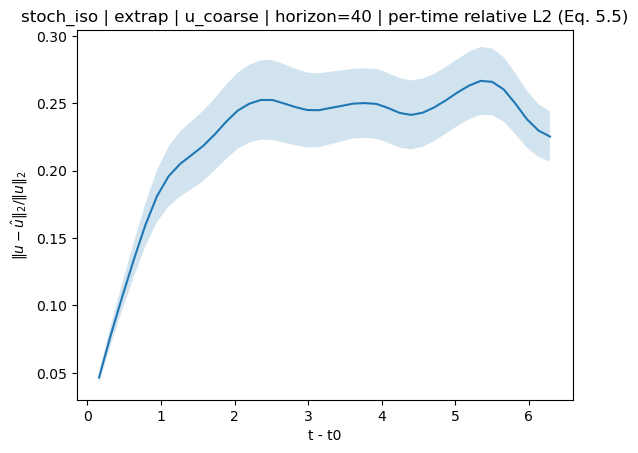

{'exp_name': 'stoch_iso', 'mse_max': np.float64(1.006638526916504), 'mse_max_ci': np.float64(0.034751386477132114), 'mse_fin': np.float64(0.2253228582441807), 'mse_fin_ci': np.float64(0.0185053731490184), 'mse_cum_fin': np.float64(0.0570581956859678), 'mse_cum_fin_ci': np.float64(0.007415538635843733)}


----------------------------------------------------------------------------------------------------
operator_norm - V_1, run 5
----------------------------------------------------------------------------------------------------


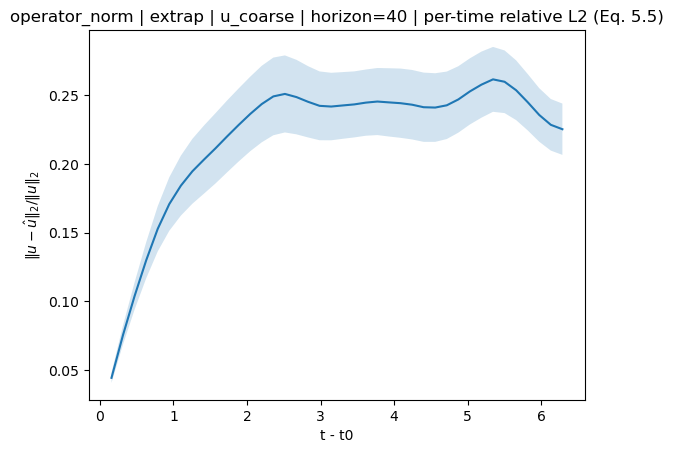

{'exp_name': 'operator_norm', 'mse_max': np.float64(1.0392329692840576), 'mse_max_ci': np.float64(0.032997748063154954), 'mse_fin': np.float64(0.22525620609521865), 'mse_fin_ci': np.float64(0.018685010650294546), 'mse_cum_fin': np.float64(0.054702883893623946), 'mse_cum_fin_ci': np.float64(0.007060235851856311)}


----------------------------------------------------------------------------------------------------
curvature - V_1, run 5
----------------------------------------------------------------------------------------------------


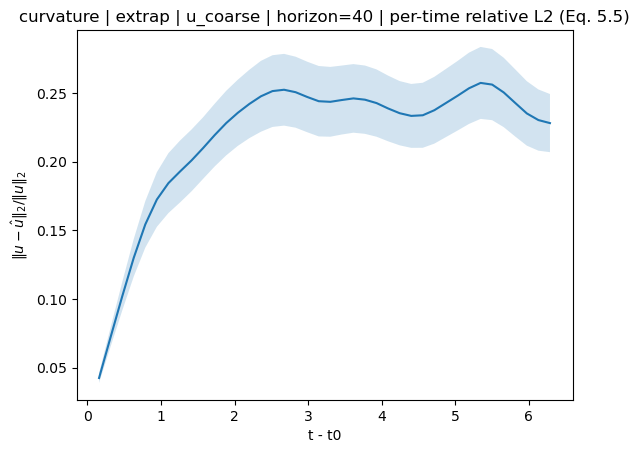

{'exp_name': 'curvature', 'mse_max': np.float64(0.9805330634117126), 'mse_max_ci': np.float64(0.03286109815982536), 'mse_fin': np.float64(0.22799719572067262), 'mse_fin_ci': np.float64(0.021150704874373594), 'mse_cum_fin': np.float64(0.054500150880776345), 'mse_cum_fin_ci': np.float64(0.007412834232701109)}


----------------------------------------------------------------------------------------------------
stiefel - V_1, run 5
----------------------------------------------------------------------------------------------------


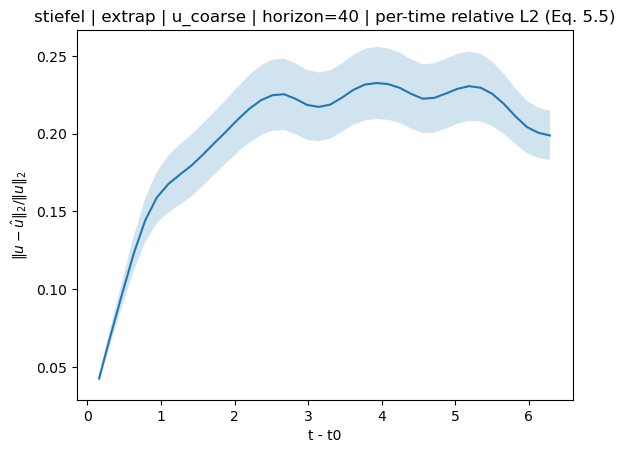

{'exp_name': 'stiefel', 'mse_max': np.float64(0.9520680904388428), 'mse_max_ci': np.float64(0.02845641217335812), 'mse_fin': np.float64(0.19880125924944878), 'mse_fin_ci': np.float64(0.015769727846512014), 'mse_cum_fin': np.float64(0.044258539546281096), 'mse_cum_fin_ci': np.float64(0.0059580704433314785)}


----------------------------------------------------------------------------------------------------
vanilla - V_1, run 6
----------------------------------------------------------------------------------------------------


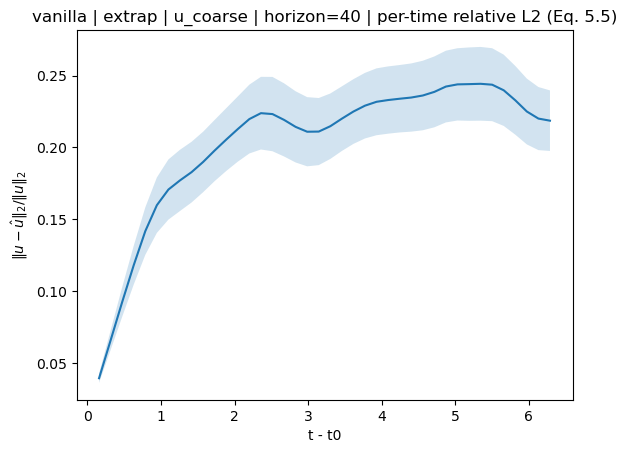

{'exp_name': 'vanilla', 'mse_max': np.float64(0.9717556834220886), 'mse_max_ci': np.float64(0.032345129775452626), 'mse_fin': np.float64(0.21857151441276074), 'mse_fin_ci': np.float64(0.021064969647847005), 'mse_cum_fin': np.float64(0.047301308801397685), 'mse_cum_fin_ci': np.float64(0.006300827821446862)}


----------------------------------------------------------------------------------------------------
stoch_iso - V_1, run 6
----------------------------------------------------------------------------------------------------


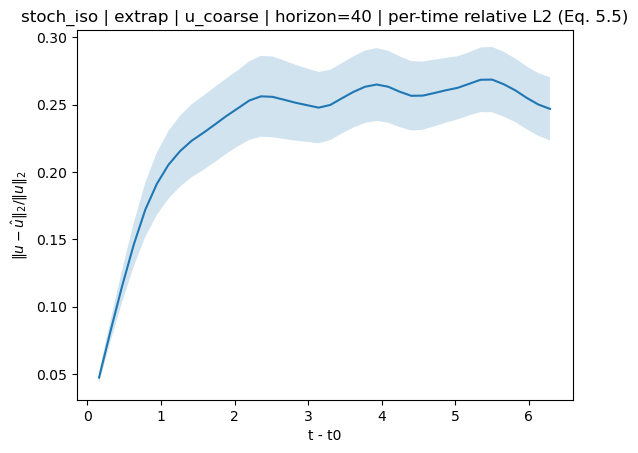

{'exp_name': 'stoch_iso', 'mse_max': np.float64(1.0763905048370361), 'mse_max_ci': np.float64(0.035774880697023), 'mse_fin': np.float64(0.24691891610622407), 'mse_fin_ci': np.float64(0.023500689751228137), 'mse_cum_fin': np.float64(0.062419859152287246), 'mse_cum_fin_ci': np.float64(0.008368352060520213)}


----------------------------------------------------------------------------------------------------
operator_norm - V_1, run 6
----------------------------------------------------------------------------------------------------


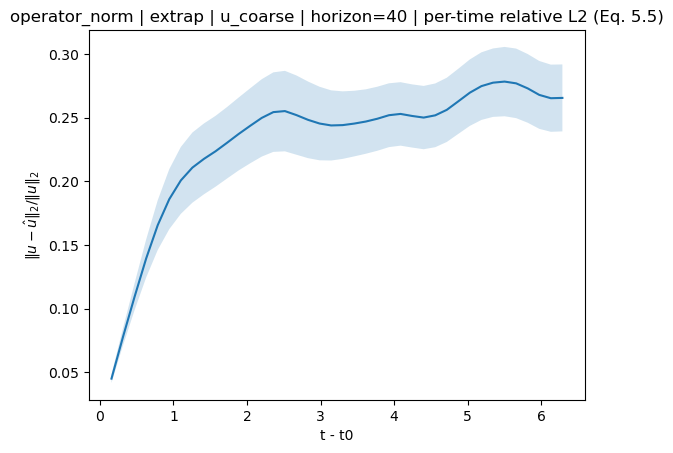

{'exp_name': 'operator_norm', 'mse_max': np.float64(1.0347377061843872), 'mse_max_ci': np.float64(0.03713195649356944), 'mse_fin': np.float64(0.265515603274107), 'mse_fin_ci': np.float64(0.026294612830251814), 'mse_cum_fin': np.float64(0.06212379930540919), 'mse_cum_fin_ci': np.float64(0.00829898133413774)}


----------------------------------------------------------------------------------------------------
curvature - V_1, run 6
----------------------------------------------------------------------------------------------------


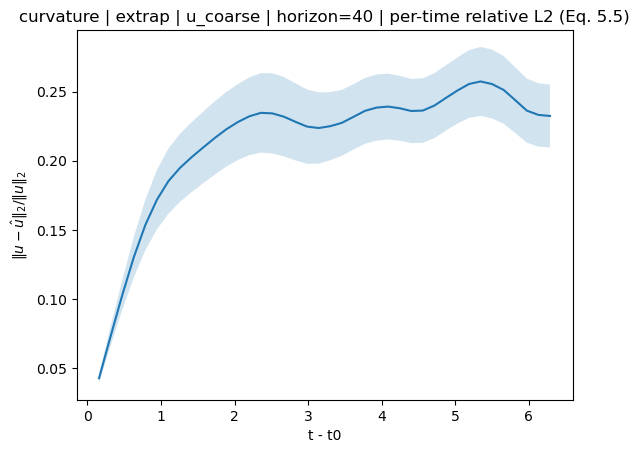

{'exp_name': 'curvature', 'mse_max': np.float64(0.9841497540473938), 'mse_max_ci': np.float64(0.0357136355080939), 'mse_fin': np.float64(0.23234555065631868), 'mse_fin_ci': np.float64(0.022775963437788274), 'mse_cum_fin': np.float64(0.05342839593067765), 'mse_cum_fin_ci': np.float64(0.007380292016978711)}


----------------------------------------------------------------------------------------------------
stiefel - V_1, run 6
----------------------------------------------------------------------------------------------------


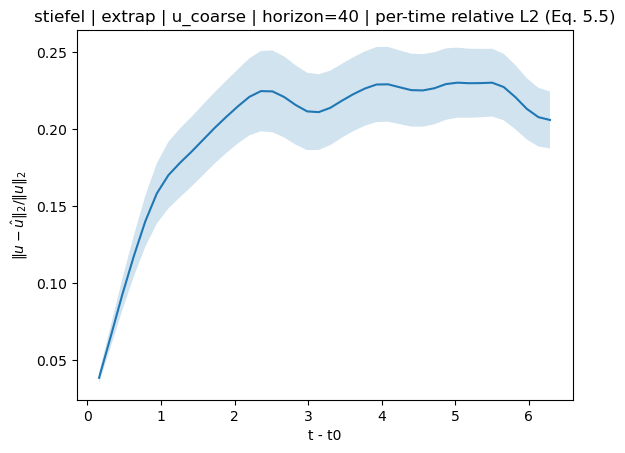

{'exp_name': 'stiefel', 'mse_max': np.float64(1.0044028759002686), 'mse_max_ci': np.float64(0.03256999820964183), 'mse_fin': np.float64(0.2060200121998787), 'mse_fin_ci': np.float64(0.018508252428427442), 'mse_cum_fin': np.float64(0.045688894465565684), 'mse_cum_fin_ci': np.float64(0.006410780786912819)}


----------------------------------------------------------------------------------------------------
vanilla - V_1, run 7
----------------------------------------------------------------------------------------------------


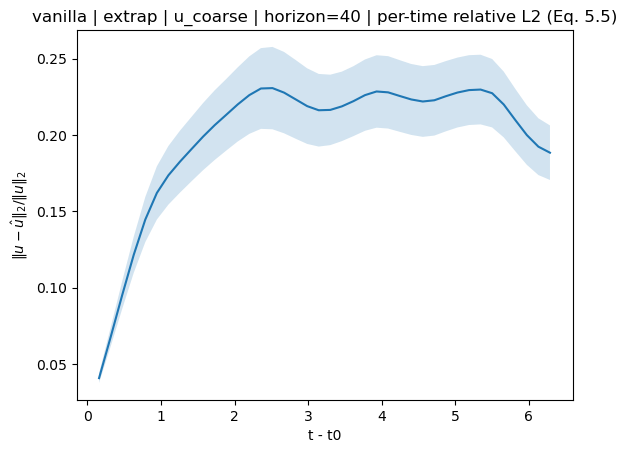

{'exp_name': 'vanilla', 'mse_max': np.float64(1.0058387517929077), 'mse_max_ci': np.float64(0.03170845748242513), 'mse_fin': np.float64(0.1884170553088188), 'mse_fin_ci': np.float64(0.01785858367352597), 'mse_cum_fin': np.float64(0.04581325573846698), 'mse_cum_fin_ci': np.float64(0.006203055572836549)}


----------------------------------------------------------------------------------------------------
stoch_iso - V_1, run 7
----------------------------------------------------------------------------------------------------


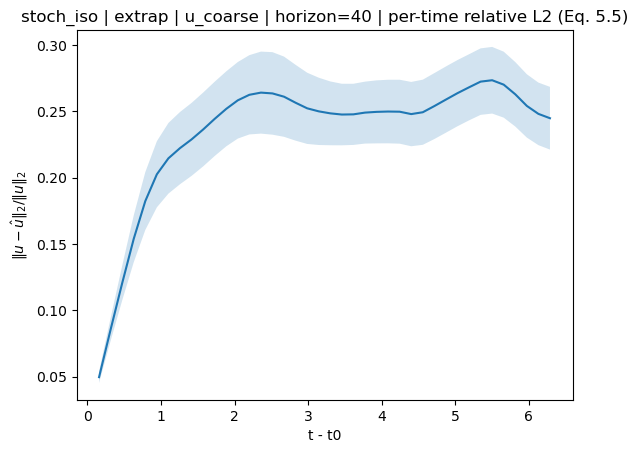

{'exp_name': 'stoch_iso', 'mse_max': np.float64(1.0285890102386475), 'mse_max_ci': np.float64(0.03701232415656102), 'mse_fin': np.float64(0.24486082285642624), 'mse_fin_ci': np.float64(0.023647332159878305), 'mse_cum_fin': np.float64(0.0626502611488104), 'mse_cum_fin_ci': np.float64(0.008028471462069415)}


----------------------------------------------------------------------------------------------------
operator_norm - V_1, run 7
----------------------------------------------------------------------------------------------------


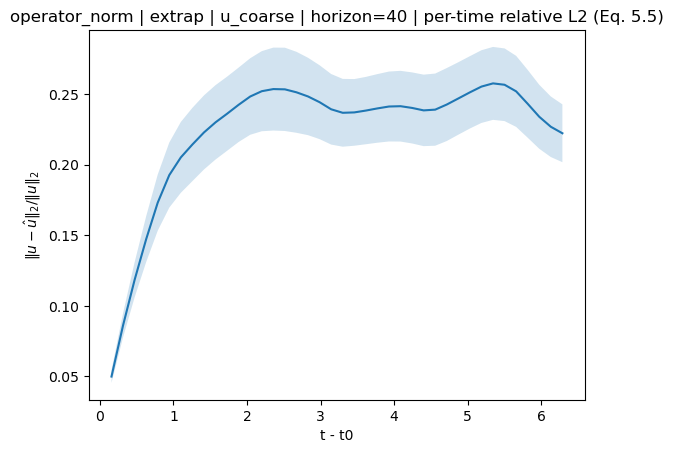

{'exp_name': 'operator_norm', 'mse_max': np.float64(1.017098307609558), 'mse_max_ci': np.float64(0.035633956967495606), 'mse_fin': np.float64(0.22225330337882043), 'mse_fin_ci': np.float64(0.020481893594027387), 'mse_cum_fin': np.float64(0.05700411438010633), 'mse_cum_fin_ci': np.float64(0.0073635710178532755)}


----------------------------------------------------------------------------------------------------
curvature - V_1, run 7
----------------------------------------------------------------------------------------------------


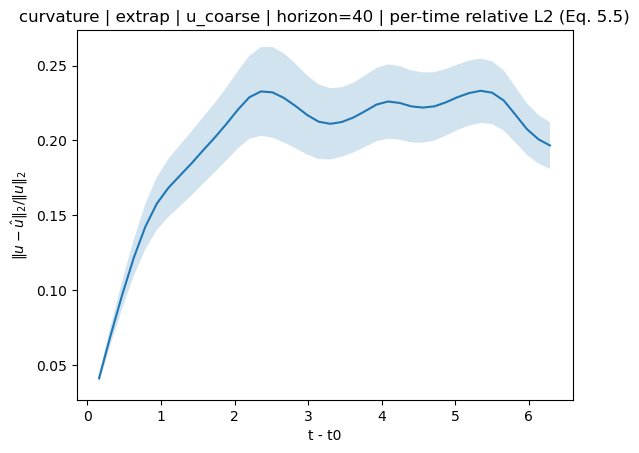

{'exp_name': 'curvature', 'mse_max': np.float64(1.0169776678085327), 'mse_max_ci': np.float64(0.03360474834233283), 'mse_fin': np.float64(0.19657466374337673), 'mse_fin_ci': np.float64(0.01560423395295507), 'mse_cum_fin': np.float64(0.04603636662475765), 'mse_cum_fin_ci': np.float64(0.006559603638963645)}


----------------------------------------------------------------------------------------------------
stiefel - V_1, run 7
----------------------------------------------------------------------------------------------------


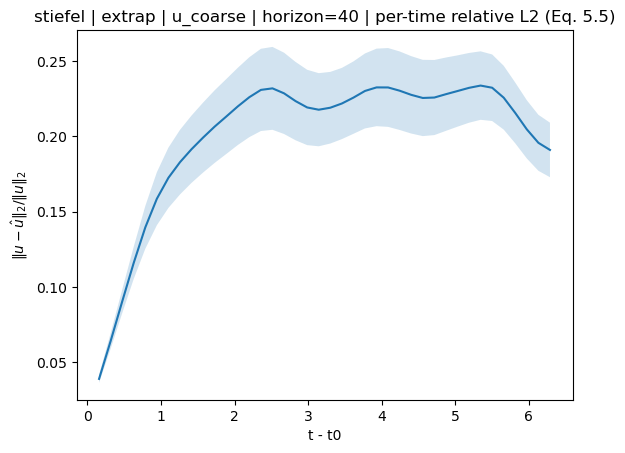

{'exp_name': 'stiefel', 'mse_max': np.float64(1.1118065118789673), 'mse_max_ci': np.float64(0.03326214648164934), 'mse_fin': np.float64(0.1909347576647997), 'mse_fin_ci': np.float64(0.018090736636704293), 'mse_cum_fin': np.float64(0.04686198221519589), 'mse_cum_fin_ci': np.float64(0.0067091156435536755)}


----------------------------------------------------------------------------------------------------
vanilla - V_1, run 8
----------------------------------------------------------------------------------------------------


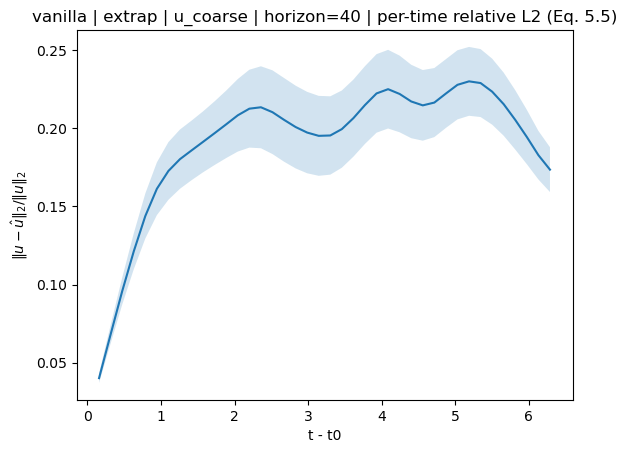

{'exp_name': 'vanilla', 'mse_max': np.float64(0.9353622794151306), 'mse_max_ci': np.float64(0.030790798742204282), 'mse_fin': np.float64(0.17358593247830867), 'mse_fin_ci': np.float64(0.014337050737601777), 'mse_cum_fin': np.float64(0.04198902463074774), 'mse_cum_fin_ci': np.float64(0.005744506154291523)}


----------------------------------------------------------------------------------------------------
stoch_iso - V_1, run 8
----------------------------------------------------------------------------------------------------


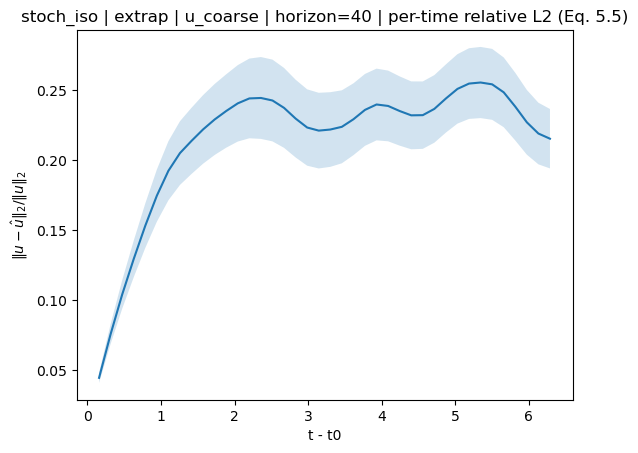

{'exp_name': 'stoch_iso', 'mse_max': np.float64(0.986483633518219), 'mse_max_ci': np.float64(0.034460218429696134), 'mse_fin': np.float64(0.2154571535438299), 'mse_fin_ci': np.float64(0.02121077048903685), 'mse_cum_fin': np.float64(0.05354215782135725), 'mse_cum_fin_ci': np.float64(0.007144651671498834)}


----------------------------------------------------------------------------------------------------
operator_norm - V_1, run 8
----------------------------------------------------------------------------------------------------


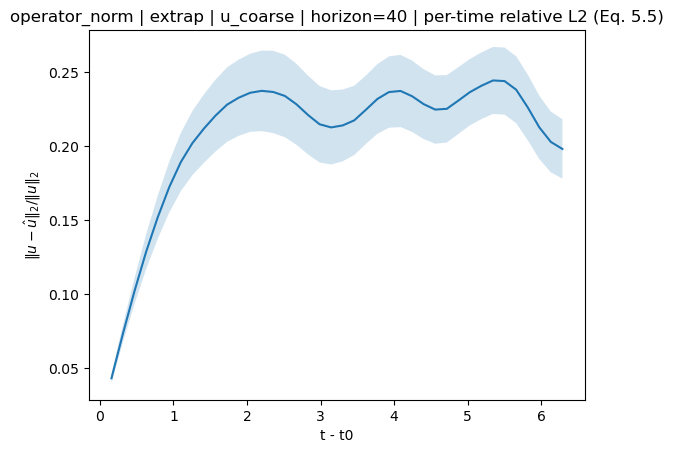

{'exp_name': 'operator_norm', 'mse_max': np.float64(0.9741736650466919), 'mse_max_ci': np.float64(0.03288265559320464), 'mse_fin': np.float64(0.19799434162676335), 'mse_fin_ci': np.float64(0.02005289197399298), 'mse_cum_fin': np.float64(0.04943390741944313), 'mse_cum_fin_ci': np.float64(0.006236859951698148)}


----------------------------------------------------------------------------------------------------
curvature - V_1, run 8
----------------------------------------------------------------------------------------------------


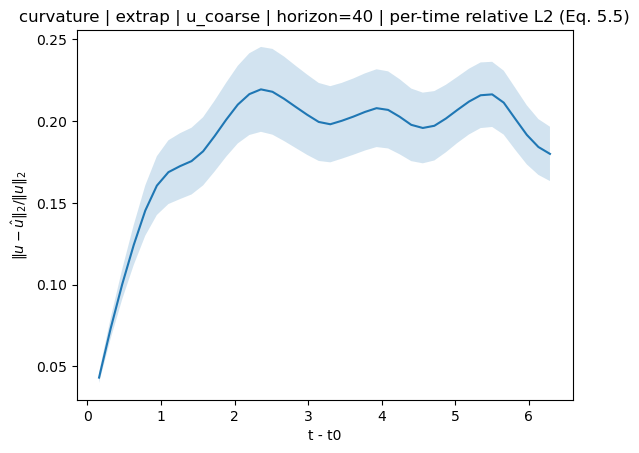

{'exp_name': 'curvature', 'mse_max': np.float64(0.9872334003448486), 'mse_max_ci': np.float64(0.030833160253276485), 'mse_fin': np.float64(0.17999736919999124), 'mse_fin_ci': np.float64(0.016616419072249887), 'mse_cum_fin': np.float64(0.04046006644144654), 'mse_cum_fin_ci': np.float64(0.0059261599666345505)}


----------------------------------------------------------------------------------------------------
stiefel - V_1, run 8
----------------------------------------------------------------------------------------------------


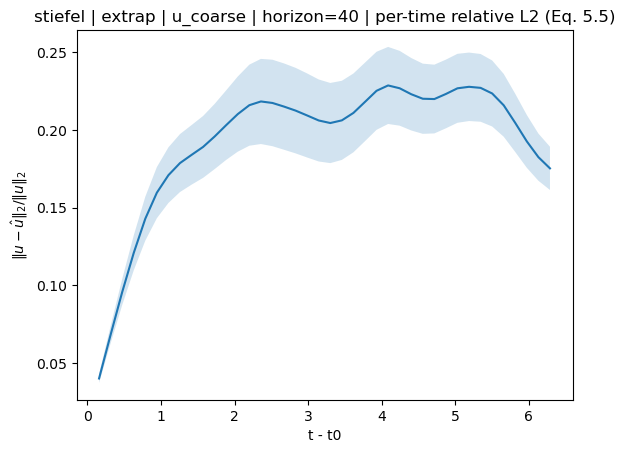

{'exp_name': 'stiefel', 'mse_max': np.float64(0.9365583658218384), 'mse_max_ci': np.float64(0.030947630128779904), 'mse_fin': np.float64(0.17525458663702012), 'mse_fin_ci': np.float64(0.013899208314858753), 'mse_cum_fin': np.float64(0.04288915002718568), 'mse_cum_fin_ci': np.float64(0.005945829132280958)}


----------------------------------------------------------------------------------------------------
vanilla - V_1, run 9
----------------------------------------------------------------------------------------------------


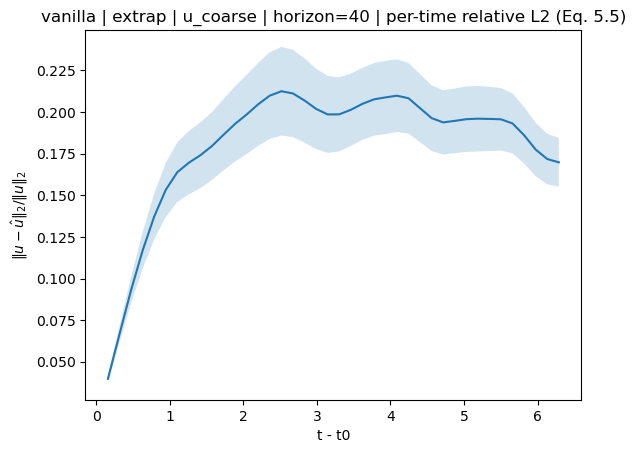

{'exp_name': 'vanilla', 'mse_max': np.float64(0.9051986932754517), 'mse_max_ci': np.float64(0.02901776930157536), 'mse_fin': np.float64(0.16981142885982992), 'mse_fin_ci': np.float64(0.014657653135610406), 'mse_cum_fin': np.float64(0.03763122639618814), 'mse_cum_fin_ci': np.float64(0.00523955162017957)}


----------------------------------------------------------------------------------------------------
stoch_iso - V_1, run 9
----------------------------------------------------------------------------------------------------


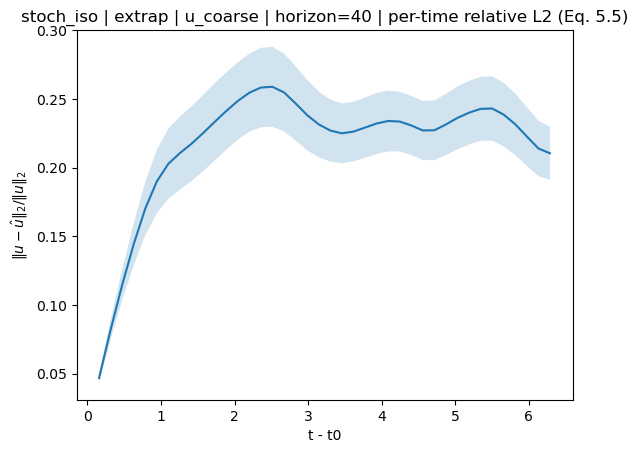

{'exp_name': 'stoch_iso', 'mse_max': np.float64(0.9642471075057983), 'mse_max_ci': np.float64(0.03455330733305792), 'mse_fin': np.float64(0.2103947377204895), 'mse_fin_ci': np.float64(0.019230485194156596), 'mse_cum_fin': np.float64(0.053502101991325615), 'mse_cum_fin_ci': np.float64(0.0068313765239175215)}


----------------------------------------------------------------------------------------------------
operator_norm - V_1, run 9
----------------------------------------------------------------------------------------------------


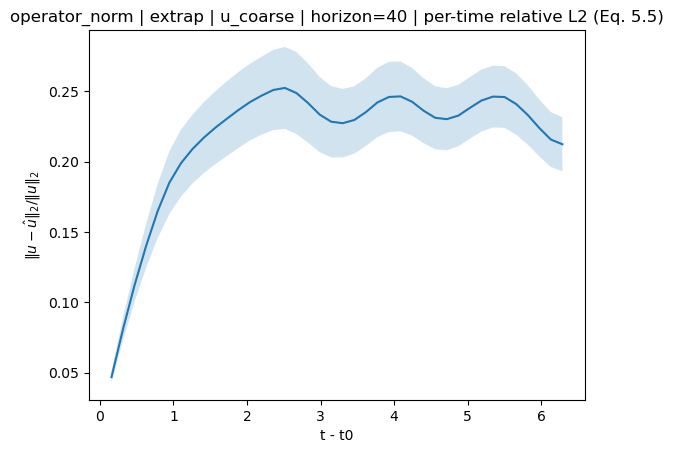

{'exp_name': 'operator_norm', 'mse_max': np.float64(0.9767084717750549), 'mse_max_ci': np.float64(0.03417937473385155), 'mse_fin': np.float64(0.21243441477417946), 'mse_fin_ci': np.float64(0.019248260357154528), 'mse_cum_fin': np.float64(0.05396681169979274), 'mse_cum_fin_ci': np.float64(0.007012150873259789)}


----------------------------------------------------------------------------------------------------
curvature - V_1, run 9
----------------------------------------------------------------------------------------------------


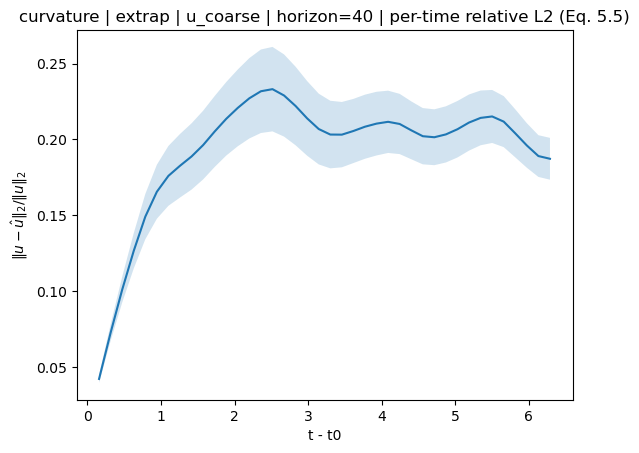

{'exp_name': 'curvature', 'mse_max': np.float64(0.9494326114654541), 'mse_max_ci': np.float64(0.02989733037458213), 'mse_fin': np.float64(0.18729184694588186), 'mse_fin_ci': np.float64(0.01376500089134277), 'mse_cum_fin': np.float64(0.04282154330983758), 'mse_cum_fin_ci': np.float64(0.006097584145327028)}


----------------------------------------------------------------------------------------------------
stiefel - V_1, run 9
----------------------------------------------------------------------------------------------------


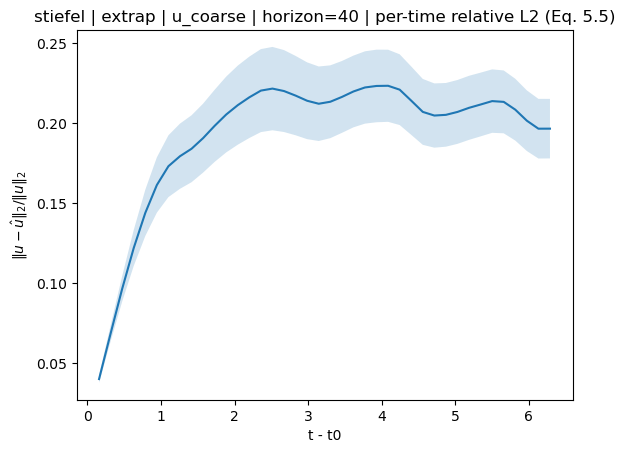

{'exp_name': 'stiefel', 'mse_max': np.float64(0.9095024466514587), 'mse_max_ci': np.float64(0.030095719470214943), 'mse_fin': np.float64(0.19641101777553557), 'mse_fin_ci': np.float64(0.018580186588439365), 'mse_cum_fin': np.float64(0.04272572168149054), 'mse_cum_fin_ci': np.float64(0.00575343125745392)}


----------------------------------------------------------------------------------------------------
vanilla - V_1, run 10
----------------------------------------------------------------------------------------------------


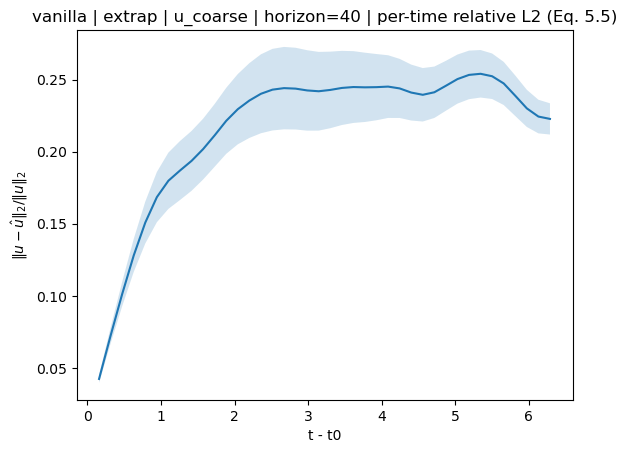

{'exp_name': 'vanilla', 'mse_max': np.float64(0.9903489947319031), 'mse_max_ci': np.float64(0.027401031702320215), 'mse_fin': np.float64(0.22271640911698343), 'mse_fin_ci': np.float64(0.010833962962219537), 'mse_cum_fin': np.float64(0.05088233780115843), 'mse_cum_fin_ci': np.float64(0.006242414981187432)}


----------------------------------------------------------------------------------------------------
stoch_iso - V_1, run 10
----------------------------------------------------------------------------------------------------


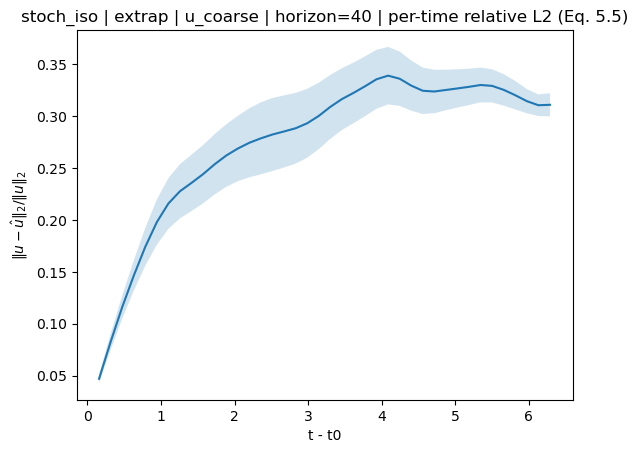

{'exp_name': 'stoch_iso', 'mse_max': np.float64(1.1108746528625488), 'mse_max_ci': np.float64(0.03076489746838727), 'mse_fin': np.float64(0.31087680578231813), 'mse_fin_ci': np.float64(0.011122423648540712), 'mse_cum_fin': np.float64(0.08160188181325793), 'mse_cum_fin_ci': np.float64(0.008753104323844935)}


----------------------------------------------------------------------------------------------------
operator_norm - V_1, run 10
----------------------------------------------------------------------------------------------------


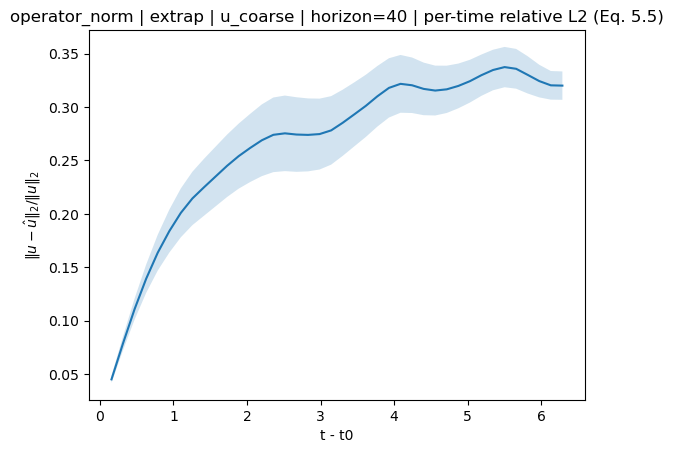

{'exp_name': 'operator_norm', 'mse_max': np.float64(1.129703164100647), 'mse_max_ci': np.float64(0.03042081195068198), 'mse_fin': np.float64(0.3200513240695), 'mse_fin_ci': np.float64(0.013270363455297744), 'mse_cum_fin': np.float64(0.07802197515964508), 'mse_cum_fin_ci': np.float64(0.008403185702934106)}


----------------------------------------------------------------------------------------------------
curvature - V_1, run 10
----------------------------------------------------------------------------------------------------


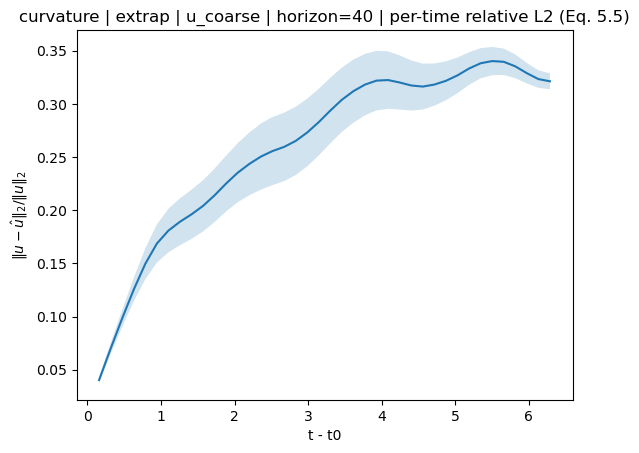

{'exp_name': 'curvature', 'mse_max': np.float64(1.073140263557434), 'mse_max_ci': np.float64(0.028066616255662938), 'mse_fin': np.float64(0.3212246721982956), 'mse_fin_ci': np.float64(0.007476590057091842), 'mse_cum_fin': np.float64(0.07502797689288855), 'mse_cum_fin_ci': np.float64(0.008138239732980402)}


----------------------------------------------------------------------------------------------------
stiefel - V_1, run 10
----------------------------------------------------------------------------------------------------


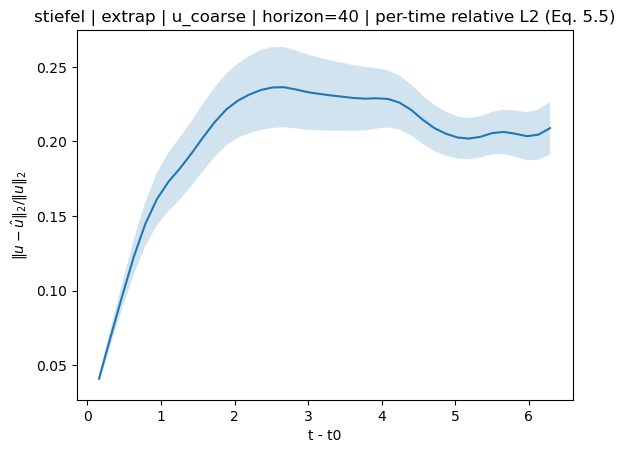

{'exp_name': 'stiefel', 'mse_max': np.float64(0.9047186374664307), 'mse_max_ci': np.float64(0.029691250243190737), 'mse_fin': np.float64(0.20891477301716804), 'mse_fin_ci': np.float64(0.017585532559910036), 'mse_cum_fin': np.float64(0.045000107884407045), 'mse_cum_fin_ci': np.float64(0.005803079520720197)}


In [37]:
stats = []
split = "extrap"

selection = "200" # "target", "best", "ema", "200"

# H = [5,40,60,80,120,160]
# H = [40,80]
H = [40]
max_mu = 50

joint_stats = {}

for version in AE_versions:
    joint_stats[f"AE-{version}"] = {}
    for run in NODE_runs:
        joint_stats[f"AE-{version}"][f"NODE-{run}"] = {}
        for h in H:
            joint_stats[f"AE-{version}"][f"NODE-{run}"][str(h)] = []
            for exp_name in experiments.keys():

                lam_reg = experiments[exp_name]["lam_reg"]
                reg_prefix = f"_{lam_reg}" if lam_reg > 0 else ""
                
                # enc = torch.load(f"output/NODE/{exp_name}_v{version}/run_{run}/enc_ft_{selection}.pt", map_location=device, weights_only=False)
                # dec = torch.load(f"output/NODE/{exp_name}_v{version}/run_{run}/dec_ft_{selection}.pt", map_location=device, weights_only=False)
                
                enc = torch.load(f"output/AE_v{version}/{exp_name}/enc_target.pt", map_location=device, weights_only=False)
                dec = torch.load(f"output/AE_v{version}/{exp_name}/dec_target.pt", map_location=device, weights_only=False)
                
                ode = torch.load(f"output/NODE/{exp_name}_v{version}/run_{run}/ode_{selection}.pt", map_location=device, weights_only=False)
                            
                t_rel, rel_mean, rel_se, cum_mean, cum_se, per_rel, per_rel_mu, per_rel_sup, rel_sup_se = relative_error_curve(
                    enc, dec, ode,
                    h5_path=path,
                    split=split,        # try "interp" too
                    field="u_coarse",
                    horizon=int(h),
                    n_starts=1,
                    start_ks=[40],
                    max_mu=max_mu,
                    method="rk4",
                    device=device,
                    relative=True
                )
            
                joint_stats[f"AE-{version}"][f"NODE-{run}"][str(h)].append({
                    "exp_name": exp_name,
                    "mse_max": np.max(per_rel_sup),
                    "mse_max_ci": rel_sup_se,
                    "mse_fin": rel_mean[-1],
                    "mse_fin_ci": rel_se[-1] ,    
                    "mse_cum_fin": cum_mean[-1],
                    "mse_cum_fin_ci": cum_se[-1]
                })
                
                print("\n")
                print("-"*100)
                print(f"{exp_name} - V_{version}, run {run}")
                print("-"*100)
                
                plot_relative_error(t_rel, rel_mean, rel_se, cum_mean, cum_se, title=f"{exp_name} | {split} | u_coarse | horizon={h}")
            
                print(joint_stats[f"AE-{version}"][f"NODE-{run}"][str(h)][-1])

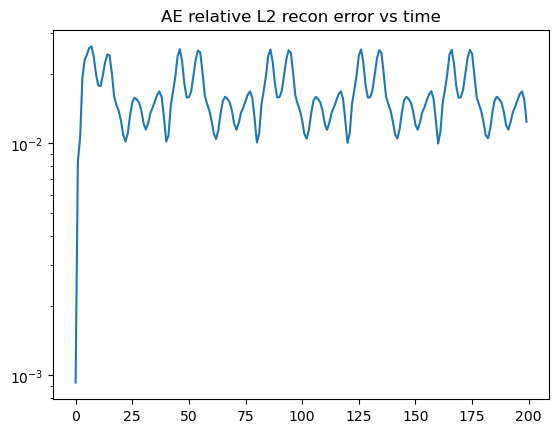

median: 0.015451727900654078 p90: 0.023724475316703318 max: 0.026193249970674515


In [15]:
import h5py, numpy as np, torch
import matplotlib.pyplot as plt

def ae_rel_err_vs_time(enc, dec, path, split="train", field="u_coarse", mu_id=0, umin=None, umax=None, device="cuda"):
    enc.eval(); dec.eval()
    with h5py.File(path, "r") as f:
        U = f[f"{split}/{field}"][mu_id]  # (Nt,H,W)
    Nt = U.shape[0]
    rel = []
    for k in range(Nt):
        u = torch.from_numpy(U[k].astype(np.float32))[None,None].to(device)
        u_n = norm_u(u, umin, umax)
        urec_n = dec(enc(u_n))
        # relative in normalized space
        rel_k = (urec_n - u_n).reshape(1,-1).norm(dim=1) / (u_n.reshape(1,-1).norm(dim=1) + 1e-8)
        rel.append(rel_k.item())
    return np.array(rel)


exp_name="vanilla"; version=1; run=1; selection="best"
# enc = torch.load(f"output/NODE/{exp_name}_v{version}/run_{run}/enc_ft_{selection}.pt", map_location=device, weights_only=False)
# dec = torch.load(f"output/NODE/{exp_name}_v{version}/run_{run}/dec_ft_{selection}.pt", map_location=device, weights_only=False)
enc = torch.load(f"output/AE_v{version}/{exp_name}/enc_{selection}.pt", map_location=device, weights_only=False)
dec = torch.load(f"output/AE_v{version}/{exp_name}/dec_{selection}.pt", map_location=device, weights_only=False)
    
rel = ae_rel_err_vs_time(enc, dec, path, split="train", field="u_coarse", mu_id=0, umin=umin, umax=umax, device=device)
plt.plot(rel); plt.yscale("log"); plt.title("AE relative L2 recon error vs time"); plt.show()
print("median:", np.median(rel), "p90:", np.quantile(rel,0.9), "max:", rel.max())


t[k0], t[k0+1] = 1.5723686954903868 1.7296055650394255
||u_true0||, ||u_true1|| = 46.12808 47.156506
||u_hat0||, ||u_hat1|| = 43.74247 42.78886


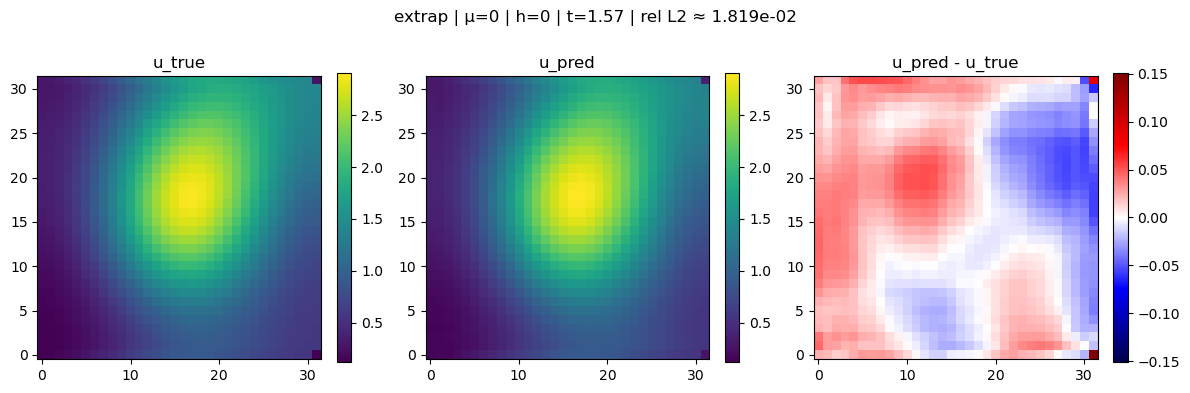

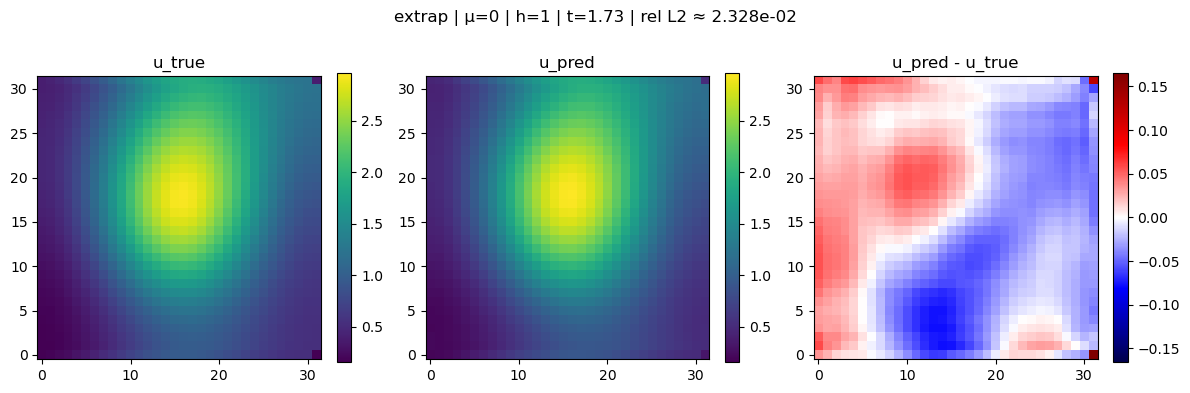

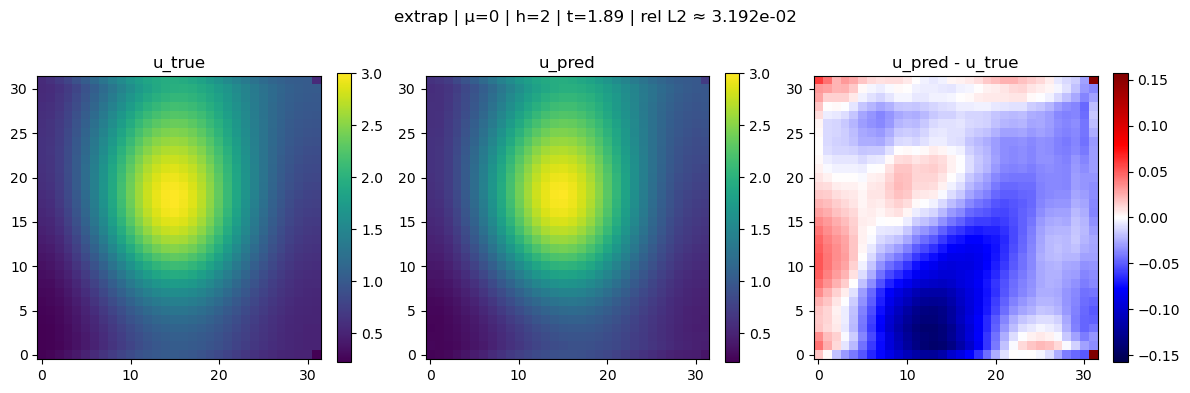

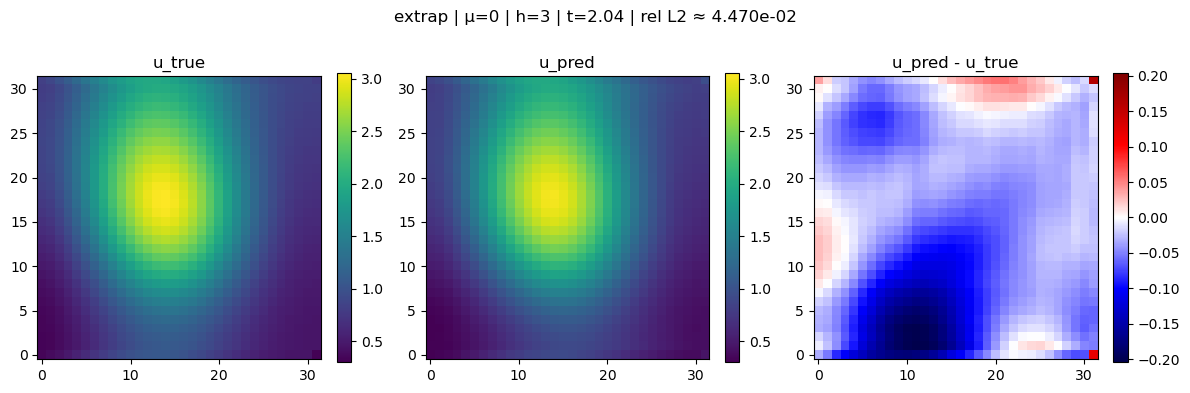

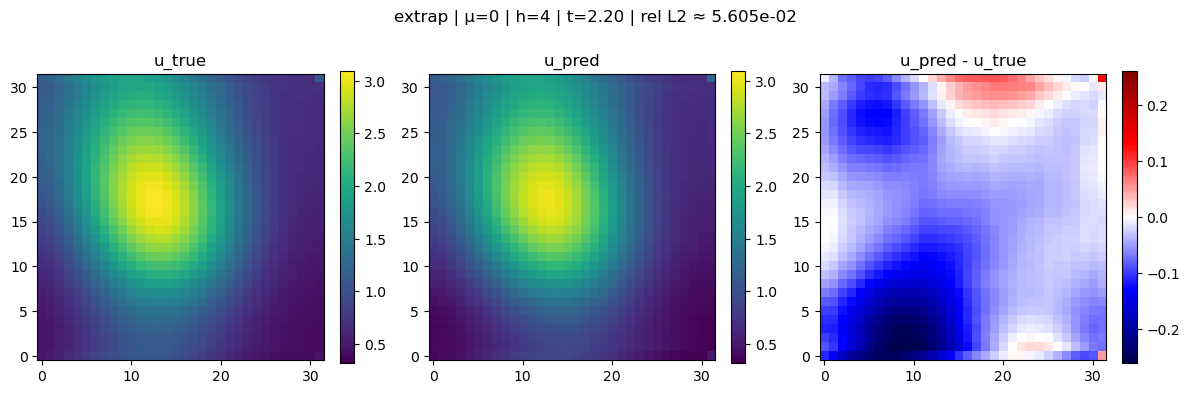

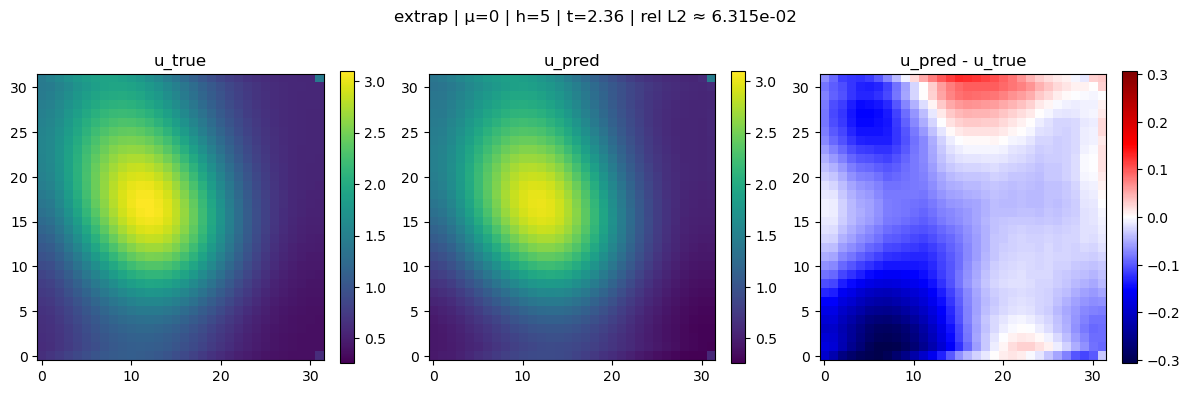

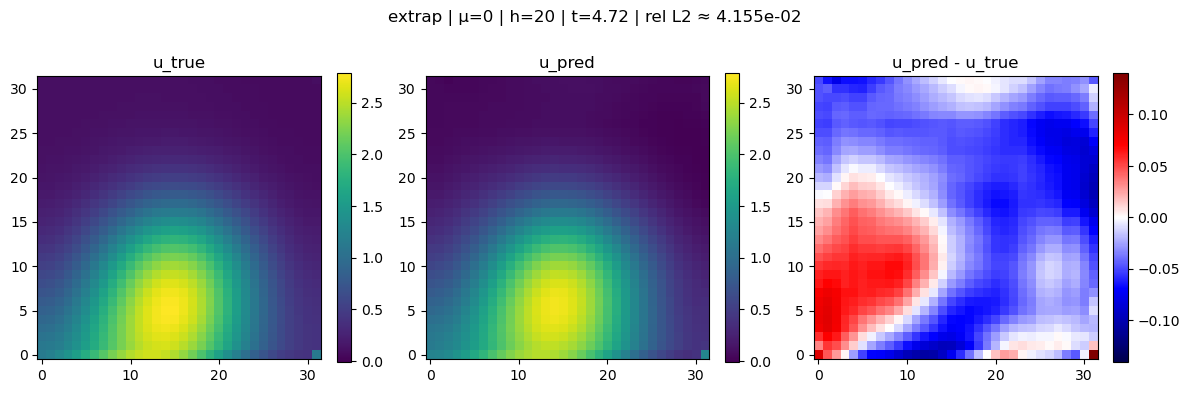

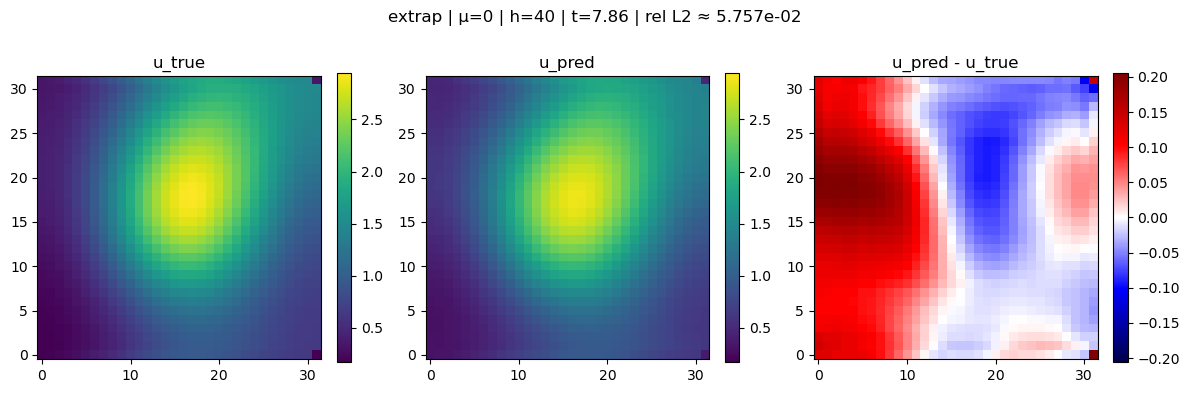

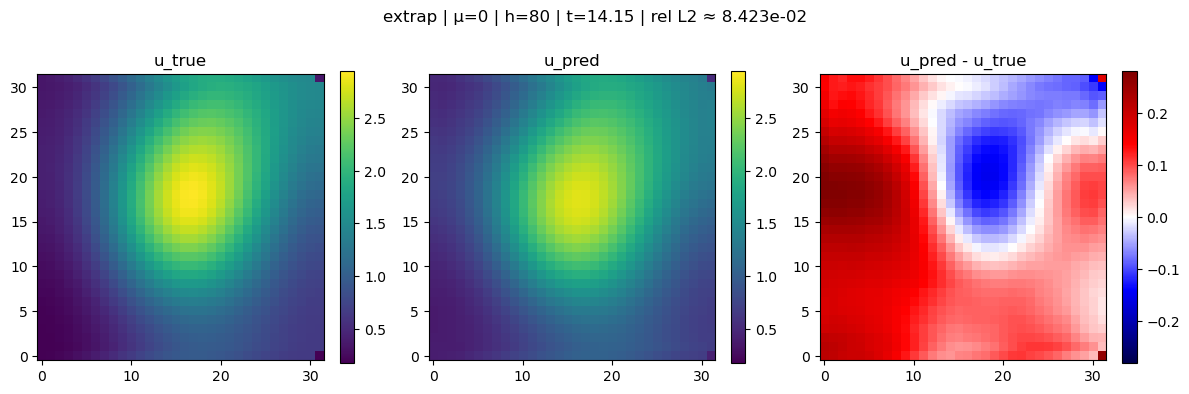

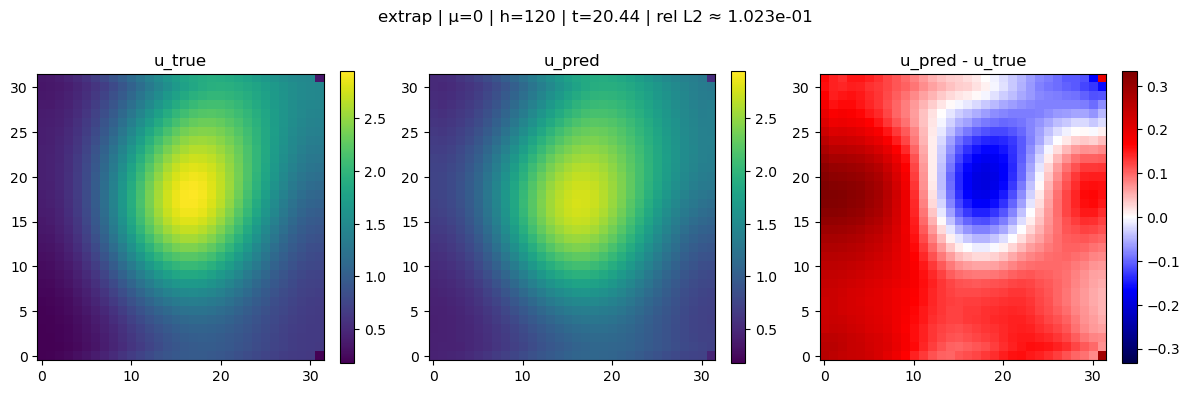

In [17]:
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

# ----------------------------
# USER SETTINGS
# ----------------------------
h5_path   = "adr_fom_fenicsx_full.h5"
split     = "extrap"          # train / interp / extrap
field     = "u_coarse"
mu_id     = 0                 # which parameter instance
k0        = 10                 # start index
horizons  = [0,1,2,3,4, 5, 20, 40, 80, 120] #, 160]
method    = "rk4"
device    = next(enc.parameters()).device
eps       = 1e-8


# ----------------------------
# LOAD DATA
# ----------------------------
with h5py.File(h5_path, "r") as f:
    U = f[f"{split}/{field}"]        # (Nmu, Nt, H, W)
    t = f["t_coarse"][:] if "coarse" in field else f["t_fine"][:]
    MU = f.get(f"{split}/mu", None)
    
    u_traj = U[mu_id]           # (Nt, H, W)
    mu = None if MU is None else MU[mu_id]

Nt, _, _ = u_traj.shape
Hmax = max(horizons)
assert k0 + Hmax < Nt

exp_name = "vanilla"
selection = "target"
version = 1
run = 1

enc = torch.load(f"output/NODE/{exp_name}_v{version}/run_{run}/enc_ft_target.pt", map_location=device, weights_only=False)
dec = torch.load(f"output/NODE/{exp_name}_v{version}/run_{run}/dec_ft_target.pt", map_location=device, weights_only=False)
ode_func = torch.load(f"output/NODE/{exp_name}_v{version}/run_{run}/ode_{selection}.pt", map_location=device, weights_only=False)
# ----------------------------
# ROLLOUT MODEL ONCE
# ----------------------------
enc.eval(); dec.eval(); ode_func.eval()

t_seg = torch.tensor(t[k0:k0+Hmax+1], dtype=torch.float32, device=device)
t_grid = t_seg.unsqueeze(0)  # (1, Hmax+1)

u0 = torch.tensor(u_traj[k0], dtype=torch.float32, device=device)[None, None]
u0 = norm_u(u0, umin, umax)
z0 = enc(u0)

if mu is None:
    mu_t = torch.zeros(1, 0, device=device)
else:
    mu_t = torch.tensor(mu, dtype=torch.float32, device=device)[None]

with torch.no_grad():
    z_traj = integrate_latent_eval(
        ode_func, z0, t_grid, mu_t, method=method
    )  # (1, Hmax+1, 1, h, w)

    z_flat = z_traj.reshape(-1, *z_traj.shape[2:])
    u_hat = dec(z_flat).reshape(1, Hmax+1, 1, H, W)[0, :, 0].cpu().numpy()

u_hat = inv_norm_u(u_hat, umin, umax)

u_true = u_traj[k0:k0+Hmax+1]


u_true0 = u_traj[k0]
u_true1 = u_traj[k0+1]
print("t[k0], t[k0+1] =", t[k0], t[k0+1])
print("||u_true0||, ||u_true1|| =", np.linalg.norm(u_true0), np.linalg.norm(u_true1))

u_hat0 = u_hat[k0]
u_hat1 = u_hat[k0+1]
print("||u_hat0||, ||u_hat1|| =", np.linalg.norm(u_hat0), np.linalg.norm(u_hat1))


# ----------------------------
# PLOTTING FUNCTION
# ----------------------------
def plot_snapshot(u_true, u_pred, title=""):
    err = u_pred - u_true
    vmax = max(u_true.max(), u_pred.max())
    vmin = min(u_true.min(), u_pred.min())
    emax = np.max(np.abs(err))

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))

    im = axs[0].imshow(u_true, origin="lower", vmin=vmin, vmax=vmax)
    axs[0].set_title("u_true")
    plt.colorbar(im, ax=axs[0], fraction=0.046)

    im = axs[1].imshow(u_pred, origin="lower", vmin=vmin, vmax=vmax)
    axs[1].set_title("u_pred")
    plt.colorbar(im, ax=axs[1], fraction=0.046)

    im = axs[2].imshow(err, origin="lower", cmap="seismic", vmin=-emax, vmax=emax)
    axs[2].set_title("u_pred - u_true")
    plt.colorbar(im, ax=axs[2], fraction=0.046)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# ----------------------------
# VISUALIZE AT SELECTED HORIZONS
# ----------------------------
for h in horizons:
    rel_L2 = np.sqrt(
        np.sum((u_hat[h] - u_true[h])**2) /
        (np.sum(u_true[h]**2) + eps)
    )

    plot_snapshot(
        u_true[h],
        u_hat[h],
        title=f"{split} | μ={mu_id} | h={h} | t={t_seg[h]:.2f} | rel L2 ≈ {rel_L2:.3e}"
    )


In [18]:
import h5py, numpy as np
with h5py.File(path, "r") as f:
    U0 = f["train/u_coarse"][:,0,:,:]
    print("max|u(t0)| =", np.max(np.abs(U0)))
    print("nonzero count =", np.count_nonzero(U0))


max|u(t0)| = 0.0
nonzero count = 0


In [19]:
for k0 in [0,1,5,10]:
    with torch.no_grad():
        u0 = torch.tensor(u_traj[k0], dtype=torch.float32, device=device)[None, None]
        u0_n = norm_u(u0, umin, umax)
        urec_n = dec(enc(u0_n))
        urec_raw = inv_norm_u(urec_n, umin, umax)
        print("k0=", k0,
              "||u0||", torch.linalg.norm(u0).item(),
              "||AErec(u0)||", torch.linalg.norm(urec_raw).item(),
              "||AErec-u0||", torch.linalg.norm(urec_raw-u0).item())


k0= 0 ||u0|| 0.0 ||AErec(u0)|| 0.1468823105096817 ||AErec-u0|| 0.1468823105096817
k0= 1 ||u0|| 13.723530769348145 ||AErec(u0)|| 14.761031150817871 ||AErec-u0|| 1.2877453565597534
k0= 5 ||u0|| 38.191680908203125 ||AErec(u0)|| 38.511451721191406 ||AErec-u0|| 0.6940661072731018
k0= 10 ||u0|| 46.12807846069336 ||AErec(u0)|| 46.193023681640625 ||AErec-u0|| 0.8407036662101746


In [20]:
with torch.no_grad():
    x = -torch.ones(1,1,32,32, device=device)
    xhat = dec(enc(x))
    print(xhat.min().item(), xhat.max().item(), xhat.mean().item())

# -1.0715705156326294 -0.7235873937606812 -0.9409432411193848


-1.0087685585021973 -0.9934297800064087 -1.0004682540893555


In [16]:
with open("joint_stats_target.json", "w") as f:
    json.dump(joint_stats, f)

In [17]:
from dataclasses import dataclass
from typing import Any, Dict, Iterable, List, Optional, Tuple, Union

import math
import numpy as np
import pandas as pd


def _to_float(x: Any) -> float:
    """Convert numpy scalars / python numbers to float, keep NaN if missing."""
    if x is None:
        return float("nan")
    # numpy scalar
    if hasattr(x, "item") and callable(getattr(x, "item")):
        try:
            return float(x.item())
        except Exception:
            pass
    try:
        return float(x)
    except Exception:
        return float("nan")


def _parse_id(s: str, prefix: str) -> Optional[int]:
    """
    Parse 'AE-1' -> 1, 'NODE-3' -> 3, '40' -> 40, returns None if cannot parse.
    """
    if s is None:
        return None
    s = str(s)
    if prefix:
        if s.startswith(prefix):
            s = s[len(prefix):]
    try:
        return int(s)
    except Exception:
        return None


def flatten_joint_stats(
    joint_stats: Dict[str, Dict[str, Dict[str, List[Dict[str, Any]]]]],
) -> pd.DataFrame:
    """
    Convert joint_stats[AE_k][NODE_k][H] = list[dict(method metrics...)]
    into a long DataFrame.

    Output columns:
      AE_key, AE, NODE_key, NODE, horizon, method,
      mse_max, mse_fin, mse_cum_fin, mse_max_ci, mse_fin_ci, mse_cum_fin_ci, ...
    """
    rows = []
    for ae_key, ae_block in joint_stats.items():
        ae_id = _parse_id(ae_key, "AE-")
        for node_key, node_block in ae_block.items():
            node_id = _parse_id(node_key, "NODE-")
            for h_key, lst in node_block.items():
                h = _parse_id(h_key, "")  # '40' -> 40
                if lst is None:
                    continue
                for d in lst:
                    method = d.get("exp_name", None)
                    row = {
                        "AE_key": ae_key,
                        "AE": ae_id,
                        "NODE_key": node_key,
                        "NODE": node_id,
                        "horizon": h,
                        "method": method,
                    }
                    # copy all numeric-ish metrics
                    for k, v in d.items():
                        if k == "exp_name":
                            continue
                        row[k] = _to_float(v)
                    rows.append(row)

    df = pd.DataFrame(rows)
    # Some safety: enforce dtypes where possible
    if "horizon" in df.columns:
        df["horizon"] = pd.to_numeric(df["horizon"], errors="coerce").astype("Int64")
    return df

import numpy as np
import pandas as pd

def _as_1d_float_array(x):
    if x is None:
        return np.array([], dtype=float)
    if isinstance(x, (list, tuple, np.ndarray, pd.Series)):
        arr = np.asarray(x, dtype=float)
        return arr.reshape(-1)
    # scalar
    return np.asarray([float(x)], dtype=float)

def _safe_nanmin(arr):
    arr = np.asarray(arr, dtype=float)
    if arr.size == 0:
        return float("nan")
    return float(np.nanmin(arr))

def _safe_nanargmin(arr):
    arr = np.asarray(arr, dtype=float)
    if arr.size == 0 or np.all(np.isnan(arr)):
        return None
    return int(np.nanargmin(arr))

def _auc_over_epochs(y):
    """
    Simple trapezoidal AUC over epoch index (0..E-1).
    Units: (loss * epochs). You can normalize later by n_epochs if desired.
    """
    y = np.asarray(y, dtype=float)
    if y.size < 2:
        return float("nan")
    x = np.arange(y.size, dtype=float)
    return float(np.trapezoid(y, x))

def _mean_first_k(y, k=10):
    y = np.asarray(y, dtype=float)
    if y.size == 0:
        return float("nan")
    return float(np.nanmean(y[: min(k, y.size)]))

def _mean_last_k(y, k=10):
    y = np.asarray(y, dtype=float)
    if y.size == 0:
        return float("nan")
    return float(np.nanmean(y[max(0, y.size - k):]))

def _epoch_reach_threshold(y, thr):
    """1-based epoch when y <= thr first happens. Returns NaN if never."""
    y = np.asarray(y, dtype=float)
    if y.size == 0 or np.isnan(thr):
        return float("nan")
    idxs = np.where(y <= thr)[0]
    if idxs.size == 0:
        return float("nan")
    return float(int(idxs[0]) + 1)

def flatten_trainval_stats(
    trainval_stats,
    *,
    ae_prefix="AE-",
    node_prefix="NODE-",
    # optional “difficulty” threshold you used before (e.g. 0.009)
    reach_val_threshold: float | None = None,
):
    """
    Accepts either:
      A) scalar dict per run: {"best_train_mse":..., "best_val_mse":...}
      B) per-epoch dict per run: {"mse_train":[...], "mse_val":[...], "lr":[...], ...}

    Returns one row per (AE_key, NODE_key, method) with derived scalar summaries.
    """
    rows = []
    for ae_key, ae_block in trainval_stats.items():
        ae_id = _parse_id(ae_key, ae_prefix)
        for node_key, node_block in ae_block.items():
            node_id = _parse_id(node_key, node_prefix)
            for method, d in node_block.items():
                row = {
                    "AE_key": ae_key,
                    "AE": ae_id,
                    "NODE_key": node_key,
                    "NODE": node_id,
                    "method": method,
                }

                if not isinstance(d, dict):
                    # unexpected, skip
                    rows.append(row)
                    continue

                # Detect per-epoch format
                is_per_epoch = ("mse_train" in d) or ("mse_val" in d) or ("lr" in d)

                if not is_per_epoch:
                    # Old scalar format: just copy numerics
                    for k, v in d.items():
                        row[k] = _to_float(v)
                    rows.append(row)
                    continue

                # --- Per-epoch format: derive summaries ---
                tr = _as_1d_float_array(d.get("mse_train"))
                va = _as_1d_float_array(d.get("mse_val"))
                lr = _as_1d_float_array(d.get("lr"))

                row["n_epochs"] = int(max(tr.size, va.size, lr.size))

                # bests
                row["best_train_mse"] = _safe_nanmin(tr)
                row["best_val_mse"] = _safe_nanmin(va)

                argmin_va = _safe_nanargmin(va)
                row["best_val_ep"] = float(argmin_va + 1) if argmin_va is not None else float("nan")

                # “best_mse/best_ep” are usually running-best traces; keep final as sanity check
                best_mse_trace = _as_1d_float_array(d.get("best_mse"))
                best_ep_trace  = _as_1d_float_array(d.get("best_ep"))
                row["best_mse_final"] = float(best_mse_trace[-1]) if best_mse_trace.size > 0 else float("nan")
                row["best_ep_final"]  = float(best_ep_trace[-1])  if best_ep_trace.size  > 0 else float("nan")

                # finals
                row["final_train_mse"] = float(tr[-1]) if tr.size > 0 else float("nan")
                row["final_val_mse"]   = float(va[-1]) if va.size > 0 else float("nan")

                # AUCs over epochs
                row["auc_train"] = _auc_over_epochs(tr)
                row["auc_val"]   = _auc_over_epochs(va)

                # early/late averages (useful for “if first 10 epochs slow -> bad run”)
                row["train_mean_first10"] = _mean_first_k(tr, 10)
                row["val_mean_first10"]   = _mean_first_k(va, 10)
                row["train_mean_last10"]  = _mean_last_k(tr, 10)
                row["val_mean_last10"]    = _mean_last_k(va, 10)

                # optional: epoch when val reaches some threshold
                if reach_val_threshold is not None:
                    row["val_ep_reach_thr"] = _epoch_reach_threshold(va, reach_val_threshold)

                # LR summaries
                row["lr_init"] = float(lr[0]) if lr.size > 0 else float("nan")
                row["lr_final"] = float(lr[-1]) if lr.size > 0 else float("nan")

                rows.append(row)

    return pd.DataFrame(rows)



def _agg_with_ci(x: pd.Series) -> Dict[str, float]:
    """Aggregate helper producing mean/std/median/min/max/n/se/ci95."""
    arr = pd.to_numeric(x, errors="coerce").dropna().to_numpy(dtype=float)
    n = int(arr.size)
    if n == 0:
        return dict(n=0, mean=np.nan, std=np.nan, median=np.nan, min=np.nan, max=np.nan,
                    se=np.nan, ci95=np.nan)
    mean = float(arr.mean())
    std = float(arr.std(ddof=0))
    se = float(std / math.sqrt(n)) if n > 0 else np.nan
    ci95 = float(1.96 * se) if n > 1 else float("nan")
    return dict(
        n=n,
        mean=mean,
        std=std,
        median=float(np.median(arr)),
        min=float(arr.min()),
        max=float(arr.max()),
        se=se,
        ci95=ci95,
    )


def _corr_pair(
    df: pd.DataFrame, x: str, y: str
) -> Dict[str, float]:
    """Pearson + Spearman on finite pairs."""
    if x not in df.columns or y not in df.columns:
        return {"n": 0, "pearson": np.nan, "spearman": np.nan}
    d = df[[x, y]].dropna()
    if len(d) < 3:
        return {"n": int(len(d)), "pearson": np.nan, "spearman": np.nan}
    pearson = float(d[x].corr(d[y], method="pearson"))
    spearman = float(d[x].corr(d[y], method="spearman"))
    return {"n": int(len(d)), "pearson": pearson, "spearman": spearman}


@dataclass
class EvalResults:
    df_long: pd.DataFrame
    df_method_horizon: pd.DataFrame
    df_method: pd.DataFrame
    df_corr_overall: pd.DataFrame
    df_corr_by_method_horizon: pd.DataFrame
    df_bad_rates: pd.DataFrame


def evaluate_stats(
    joint_stats: Dict[str, Dict[str, Dict[str, List[Dict[str, Any]]]]],
    *,
    trainval_stats: Optional[Dict[str, Dict[str, Dict[str, Dict[str, Any]]]]] = None,
    rollout_metrics: Iterable[str] = ("mse_max", "mse_fin", "mse_cum_fin"),
    horizons: Optional[Iterable[int]] = None,
    methods: Optional[Iterable[str]] = None,
    # correlation settings (only if trainval_stats provided)
    train_metrics: Iterable[str] = ("best_train_mse", "best_val_mse"),
    corr_against_rollout: Iterable[str] = ("mse_cum_fin", "mse_fin", "mse_max"),
    corr_horizons: Iterable[int] = (40, 80, 120),
    # optional "bad run" thresholds; set None to disable a threshold
    bad_thresholds: Optional[Dict[str, Optional[float]]] = None,
) -> EvalResults:
    """
    Main evaluation entry point.

    Returns EvalResults with:
      - df_long: rollout results, long form (AE,NODE,horizon,method, metrics...)
      - df_method_horizon: aggregates by (method,horizon)
      - df_method: aggregates by (method) pooled across selected horizons
      - df_corr_overall: overall correlations between train metrics and rollout metrics
      - df_corr_by_method_horizon: correlations stratified by (method, horizon)
      - df_bad_rates: fraction of runs exceeding "bad" thresholds by (method,horizon)

    Notes:
      - Aggregates are computed over (AE,NODE) runs.
      - If you pass horizons/methods, they filter df_long before aggregation.
    """
    df = flatten_joint_stats(joint_stats)

    # Filter by horizons/methods if requested
    if horizons is not None:
        horizons_set = set(int(h) for h in horizons)
        df = df[df["horizon"].astype("Int64").isin(list(horizons_set))]
    if methods is not None:
        methods_set = set(str(m) for m in methods)
        df = df[df["method"].astype(str).isin(methods_set)]

    # ---- Aggregation by (method, horizon)
    mh_rows = []
    for (method, horizon), g in df.groupby(["method", "horizon"], dropna=False):
        row = {"method": method, "horizon": int(horizon) if pd.notna(horizon) else None}
        for m in rollout_metrics:
            stats = _agg_with_ci(g[m]) if m in g.columns else _agg_with_ci(pd.Series([], dtype=float))
            # prefix columns like mse_cum_fin_mean, mse_cum_fin_std, ...
            for k, v in stats.items():
                row[f"{m}_{k}"] = v
        mh_rows.append(row)
    df_method_horizon = pd.DataFrame(mh_rows).sort_values(["horizon", "method"])

    # ---- Aggregation by method pooled across horizons (use filtered df)
    m_rows = []
    for method, g in df.groupby(["method"], dropna=False):
        row = {"method": method}
        for m in rollout_metrics:
            stats = _agg_with_ci(g[m]) if m in g.columns else _agg_with_ci(pd.Series([], dtype=float))
            for k, v in stats.items():
                row[f"{m}_{k}"] = v
        m_rows.append(row)
    df_method = pd.DataFrame(m_rows).sort_values("method")

    # ---- Bad run rates
    # bad_thresholds example:
    #   {"mse_max": 0.8, "mse_cum_fin": 60.0, "mse_fin": 0.6}
    if bad_thresholds is None:
        bad_thresholds = {}  # no thresholds => empty output

    bad_rows = []
    if len(bad_thresholds) > 0:
        for (method, horizon), g in df.groupby(["method", "horizon"], dropna=False):
            row = {"method": method, "horizon": int(horizon) if pd.notna(horizon) else None, "n": int(len(g))}
            for metric, thr in bad_thresholds.items():
                if thr is None or metric not in g.columns:
                    continue
                bad = (pd.to_numeric(g[metric], errors="coerce") > float(thr)).astype(float)
                row[f"bad_rate_{metric}_gt_{thr:g}"] = float(bad.mean())
            bad_rows.append(row)
    df_bad_rates = pd.DataFrame(bad_rows).sort_values(["horizon", "method"]) if bad_rows else pd.DataFrame()

    # ---- Correlations: require trainval_stats
    df_corr_overall = pd.DataFrame()
    df_corr_by_method_horizon = pd.DataFrame()

    if trainval_stats is not None:
        df_tv = flatten_trainval_stats(
            trainval_stats,
            reach_val_threshold=0.009,  # optional; or None
        )
    
        dfm = df.merge(df_tv, on=["AE_key", "NODE_key", "method", "AE", "NODE"], how="left")
    

        # Overall correlations at specific horizons (pooled over methods OR stratify later)
        overall_rows = []
        for H in corr_horizons:
            dH = dfm[dfm["horizon"].astype("Int64") == int(H)]
            for tm in train_metrics:
                for rm in corr_against_rollout:
                    out = _corr_pair(dH, tm, rm)
                    overall_rows.append({
                        "horizon": int(H),
                        "train_metric": tm,
                        "rollout_metric": rm,
                        **out
                    })
        df_corr_overall = pd.DataFrame(overall_rows)

        # Correlations by (method, horizon)
        by_rows = []
        for (method, H), g in dfm.groupby(["method", "horizon"], dropna=False):
            if pd.isna(H):
                continue
            H = int(H)
            if H not in set(int(x) for x in corr_horizons):
                continue
            for tm in train_metrics:
                for rm in corr_against_rollout:
                    out = _corr_pair(g, tm, rm)
                    by_rows.append({
                        "method": method,
                        "horizon": H,
                        "train_metric": tm,
                        "rollout_metric": rm,
                        **out
                    })
        df_corr_by_method_horizon = pd.DataFrame(by_rows).sort_values(
            ["horizon", "method", "train_metric", "rollout_metric"]
        )

    return EvalResults(
        df_long=df.reset_index(drop=True),
        df_method_horizon=df_method_horizon.reset_index(drop=True),
        df_method=df_method.reset_index(drop=True),
        df_corr_overall=df_corr_overall.reset_index(drop=True),
        df_corr_by_method_horizon=df_corr_by_method_horizon.reset_index(drop=True),
        df_bad_rates=df_bad_rates.reset_index(drop=True),
    )



In [18]:
trainval_epoch_dict = {}

for version in AE_versions:
    trainval_epoch_dict[f"AE-{version}"] = {}
    for node_seed in NODE_runs:
        trainval_epoch_dict[f"AE-{version}"][f"NODE-{node_seed}"] = {}
        for exp_name in experiments:

            filename = f"output/NODE/{exp_name}_v{version}/run_{node_seed}/stats.json"        
            with open(filename, "r") as f:
                data = json.load(f)
                trainval_epoch_dict[f"AE-{version}"][f"NODE-{node_seed}"][exp_name] = data

In [19]:
joint_stats

{'AE-1': {'NODE-1': {'5': [{'exp_name': 'vanilla',
     'mse_max': np.float64(9.538172721862793),
     'mse_max_ci': np.float64(0.1988827262295148),
     'mse_fin': np.float64(3.693709884881973),
     'mse_fin_ci': np.float64(0.19956138131137552),
     'mse_cum_fin': np.float64(49.59270522594452),
     'mse_cum_fin_ci': np.float64(5.090321427081337)},
    {'exp_name': 'stoch_iso',
     'mse_max': np.float64(11.568278312683105),
     'mse_max_ci': np.float64(0.26063369673686054),
     'mse_fin': np.float64(4.63972074508667),
     'mse_fin_ci': np.float64(0.2618581516244639),
     'mse_cum_fin': np.float64(76.0660130739212),
     'mse_cum_fin_ci': np.float64(7.821679139237704)},
    {'exp_name': 'operator_norm',
     'mse_max': np.float64(10.877535820007324),
     'mse_max_ci': np.float64(0.24735243304293936),
     'mse_fin': np.float64(4.258463072776794),
     'mse_fin_ci': np.float64(0.2488914032967955),
     'mse_cum_fin': np.float64(67.46437613248825),
     'mse_cum_fin_ci': np.float

In [20]:


results = evaluate_stats(
    joint_stats,
    trainval_stats=trainval_epoch_dict,
    train_metrics=("best_val_mse", "best_val_ep", "auc_val", "val_mean_first10", "val_ep_reach_thr"),
    corr_against_rollout=("mse_cum_fin", "mse_fin", "mse_max"),
    corr_horizons=H,
)

print(results.df_corr_overall)

    horizon      train_metric rollout_metric   n   pearson  spearman
0         5      best_val_mse    mse_cum_fin  50  0.265140  0.294886
1         5      best_val_mse        mse_fin  50  0.279425  0.281921
2         5      best_val_mse        mse_max  50  0.174855  0.150060
3         5       best_val_ep    mse_cum_fin  50 -0.002388 -0.069743
4         5       best_val_ep        mse_fin  50  0.014082 -0.060363
..      ...               ...            ...  ..       ...       ...
85      160  val_mean_first10        mse_fin  50 -0.078709 -0.017911
86      160  val_mean_first10        mse_max  50  0.040483  0.011188
87      160  val_ep_reach_thr    mse_cum_fin   0       NaN       NaN
88      160  val_ep_reach_thr        mse_fin   0       NaN       NaN
89      160  val_ep_reach_thr        mse_max   0       NaN       NaN

[90 rows x 6 columns]


In [65]:
# results.df_long

In [21]:
# results_df: output table from evaluate_stats() (one row per method x horizon)
AE = 1
for h in H:
    
    summary = (
        results.df_long.query(f"AE == @AE and horizon == @h")
          .groupby("method", as_index=False)
          .agg(
              n=("NODE", "nunique"),
              mse_cum_mean=("mse_cum_fin", "mean"),
              mse_cum_std =("mse_cum_fin", "std"),
              mse_max_mean=("mse_max", "mean"),
              mse_max_std =("mse_max", "std"),
          )
          .sort_values("mse_cum_mean")
    )

    print(f"Horizon = {h}")
    print(summary)
    print("-"*100, "\n")


Horizon = 5
          method   n  mse_cum_mean  mse_cum_std  mse_max_mean  mse_max_std
4        vanilla  10     64.350862    10.083056     10.894741     1.309270
2        stiefel  10     65.982291     9.760194     11.372173     1.172052
0      curvature  10     69.700485     4.677393     11.348690     0.680151
3      stoch_iso  10     84.666771     7.895132     12.455945     0.983836
1  operator_norm  10     84.737100    10.043956     12.461019     1.080324
---------------------------------------------------------------------------------------------------- 

Horizon = 40
          method   n  mse_cum_mean  mse_cum_std  mse_max_mean  mse_max_std
2        stiefel  10   1972.329848   210.999757     25.339056     1.404997
4        vanilla  10   1995.717151   230.517949     25.447836     1.409214
0      curvature  10   2057.260474   234.044601     26.411518     1.454612
1  operator_norm  10   2256.151915   217.377210     27.276344     1.680346
3      stoch_iso  10   2378.196100   218.460660

In [22]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

def paired_deltas_vs_baseline(df, metric="mse_cum_fin", baseline="vanilla"):
    # df: long-form rollouts
    # returns long-form deltas for each (AE, NODE, horizon, method)

    keys = ["AE_key", "NODE_key", "horizon"]
    wide = df.pivot_table(index=keys, columns="method", values=metric, aggfunc="first")

    if baseline not in wide.columns:
        raise ValueError(f"Baseline '{baseline}' not found in methods: {list(wide.columns)}")

    deltas = wide.sub(wide[baseline], axis=0)  # subtract baseline per row
    deltas = deltas.drop(columns=[baseline], errors="ignore")

    out = (
        deltas.stack()
              .rename("delta")
              .reset_index()
              .rename(columns={"level_3": "method"})
    )
    # also keep the baseline value if useful
    out["baseline_value"] = wide[baseline].values.repeat(len(deltas.columns))
    return out


def summarize_paired_deltas(delta_df):
    # delta_df: output of paired_deltas_vs_baseline
    g = delta_df.groupby(["horizon", "method"])["delta"]
    return g.agg(
        n="count",
        mean="mean",
        std="std",
        median="median",
        min="min",
        max="max",
        se=lambda x: x.std(ddof=1)/np.sqrt(len(x)) if len(x) > 1 else np.nan,
    ).reset_index().sort_values(["horizon", "mean"])



def paired_wilcoxon(df, metric="mse_cum_fin", baseline="vanilla"):
    deltas = paired_deltas_vs_baseline(df, metric=metric, baseline=baseline)

    rows = []
    for (h, m), sub in deltas.groupby(["horizon", "method"]):
        x = sub["delta"].dropna().to_numpy()
        n = len(x)
        if n < 5:
            p = np.nan
        else:
            # Wilcoxon tests median(delta)=0
            # if you want "method better than baseline" use alternative="less"
            p = wilcoxon(x, alternative="two-sided").pvalue
        rows.append({"horizon": h, "method": m, "n": n, "p_wilcoxon": p,
                     "delta_mean": x.mean() if n else np.nan,
                     "delta_median": np.median(x) if n else np.nan})
    return pd.DataFrame(rows).sort_values(["horizon", "p_wilcoxon"])


In [39]:


for h in H: 

    print("\n")
    print("-"*100)
    print(f"Horizon = {h}")
    print("-"*100)

    df = results.df_long
    df = df[df["horizon"] == h]

    metric_name = "mse_cum_fin" # "mse_cum_fin" "mse_max"

    # d = paired_deltas_vs_baseline(df, metric="mse_cum_fin", baseline="vanilla")
    d = paired_deltas_vs_baseline(df, metric=metric_name, baseline="vanilla")
    # summary = summarize_paired_deltas(d)
    # print(summary)

    for exp_name in [x for x in experiments if x != "vanilla"]:
        print(exp_name)
        deltas = d[d["method"]==exp_name]
        summary = summarize_paired_deltas(deltas)
        print(f'MEAN: {summary["mean"][0]:.4f}, SE: {summary["se"][0]:.4f}')        
        p = wilcoxon(deltas["delta"], alternative="less").pvalue  # tests delta < 0
        print(f"p-value of `{metric_name} lower than vanilla` hypothesis: {p}\n")

        



----------------------------------------------------------------------------------------------------
Horizon = 40
----------------------------------------------------------------------------------------------------
stoch_iso
MEAN: 382.4789, SE: 66.6992
p-value of `mse_cum_fin lower than vanilla` hypothesis: 1.0

operator_norm
MEAN: 260.4348, SE: 37.3363
p-value of `mse_cum_fin lower than vanilla` hypothesis: 1.0

curvature
MEAN: 61.5433, SE: 76.8301
p-value of `mse_cum_fin lower than vanilla` hypothesis: 0.8125

stiefel
MEAN: -23.3873, SE: 46.1464
p-value of `mse_cum_fin lower than vanilla` hypothesis: 0.2783203125

